# Diabetes Prediction


## 1. Problem Statement

Diabetes is a chronic metabolic disorder that affects millions of people worldwide and is a leading cause of cardiovascular disease, kidney failure, vision impairment, and other serious health complications. Early detection is essential for initiating timely treatment and preventive interventions; however, traditional screening methods often require clinical examinations, laboratory investigations, and specialist consultation, which may not always be accessible or cost-effective.

The availability of healthcare and lifestyle data presents an opportunity to develop intelligent predictive systems that can identify individuals at risk of diabetes before severe complications arise. The Diabetes Health Indicators Dataset contains demographic, behavioral, and health-related attributes that can be utilized to build accurate predictive models.

The problem addressed in this project is to develop a machine learning model capable of accurately classifying individuals as diabetic or non-diabetic based on their health indicators. The system aims to analyze multiple risk factors, identify the most influential predictors of diabetes, and provide a reliable decision-support tool that can assist healthcare professionals in early screening and preventive healthcare planning.

## 2. About the Data

**Source:** https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

| Column | Meaning |
|---|---|
| Diabetes_binary | Target:0 = no diabetes 1 = prediabetes or diabetes |
| HighBP | 0 = no high BP<br><br> 1 = high BP |
| HighChol | 0 = no high cholesterol<br><br> 1 = high cholesterol |
| CholCheck | 0 = no cholesterol check in 5 years<br><br> 1 = yes cholesterol check in 5 years |
| BMI | Body Mass Index |
| Smoker | Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] <br><br>0 = no<br><br> 1 = yes |
| Stroke | (Ever told) you had a stroke.<br><br> 0 = no <br><br>1 = yes |
| HeartDiseaseorAttack | coronary heart disease (CHD) or myocardial infarction (MI)<br><br> 0 = no<br><br> 1 = yes |
| PhysActivity | physical activity in past 30 days - not including job<br><br> 0 = no<br><br> 1 = yes |
| Fruits | Consume Fruit 1 or more times per day <br><br>0 = no <br><br>1 = yes |
| Veggies | Consume Vegetables 1 or more times per day <br><br>0 = no<br><br> 1 = yes |
| HvyAlcoholConsump | Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 <br><br> drinks per week) <br><br>0 = no <br><br>1 = yes |
| AnyHealthcare | Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc.<br><br> 0 = no<br><br> 1 = yes |
| NoDocbcCost | Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?<br><br> 0 = no<br><br> 1 = yes |
| GenHlth | Would you say that in general your health is: scale 1-5 <br><br>1 = excellent<br><br> 2 = very good<br><br> 3 = good <br><br>4 = fair <br><br>5 = poor |
| MentHlth | Now thinking about your mental health, which includes stress, depression, and problems with emotions,<br><br> for how many days during the past 30 days was your mental health not good? scale 1-30 days |
| PhysHlth | Now thinking about your physical health, which includes physical illness and injury, for how many days<br><br> during the past 30 days was your physical health not good? scale 1-30 days |
| DiffWalk | Do you have serious difficulty walking or climbing stairs?<br><br> 0 = no<br><br> 1 = yes |
| Sex | 0 = female 1 = male |
| Age | 13-level age category (_AGEG5YR see codebook)<br><br> 1 = 18-24 <br><br>9 = 60-64<br><br> 13 = 80 or older |
| Education | Education level (EDUCA see codebook) scale 1-6 <br><br>1 = Never attended school or only kindergarten <br><br>2 = Grades 1 through 8 (Elementary) <br><br>3 = Grades 9 through 11 (Some high school) <br><br>4 = Grade 12 or GED (High school graduate) <br><br>5 = College 1 year to 3 years (Some college or technical school) <br><br>6 = College 4 years or more (College graduate) |
| Income | Income scale (INCOME2 see codebook) scale 1-8<br><br> 1 = less than \$10,000 <br><br> 5 = less than \$35,000<br><br> 8 = \$75,000 or more |



## 3. Importing Libraries





In [157]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif

#from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


In [158]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [159]:
#importing the dataset
file_path = '/content/drive/MyDrive/dataset/DAIBETIC ORGINAL DATA.csv'
df = pd.read_csv(file_path)

## 4. Understanding the Data

This section performs an initial inspection of the raw dataset — its size, structure, feature types, value ranges, and data quality (missing values and duplicates) — before any transformation is applied.

**Shape of the dataset** (rows × columns):

In [191]:
df.shape

(70692, 22)

**Column names:**

In [192]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

**Data types and non-null counts** for each column:

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       70692 non-null  int64
 1   HighBP                70692 non-null  int64
 2   HighChol              70692 non-null  int64
 3   CholCheck             70692 non-null  int64
 4   BMI                   70692 non-null  int64
 5   Smoker                70692 non-null  int64
 6   Stroke                70692 non-null  int64
 7   HeartDiseaseorAttack  70692 non-null  int64
 8   PhysActivity          70692 non-null  int64
 9   Fruits                70692 non-null  int64
 10  Veggies               70692 non-null  int64
 11  HvyAlcoholConsump     70692 non-null  int64
 12  AnyHealthcare         70692 non-null  int64
 13  NoDocbcCost           70692 non-null  int64
 14  GenHlth               70692 non-null  int64
 15  MentHlth              70692 non-null  int64
 16  Phys

**First 5 records:**

In [194]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,0,1,26,0,0,0,1,0,...,1,0,3,5,30,0,1,4,6,8
1,0,1,1,1,26,1,1,0,0,1,...,1,0,3,0,0,0,1,12,6,8
2,0,0,0,1,26,0,0,0,1,1,...,1,0,1,0,10,0,1,13,6,8
3,0,1,1,1,28,1,0,0,1,1,...,1,0,3,0,3,0,1,11,6,8
4,0,0,0,1,29,1,0,0,1,1,...,1,0,2,0,0,0,0,8,5,8


**Last 5 records:**

In [195]:
df.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
70687,1,0,1,1,37,0,0,0,0,0,...,1,0,4,0,0,0,0,6,4,1
70688,1,0,1,1,29,1,0,1,0,1,...,1,0,2,0,0,1,1,10,3,6
70689,1,1,1,1,25,0,0,1,0,1,...,1,0,5,15,0,1,0,13,6,4
70690,1,1,1,1,18,0,0,0,0,0,...,1,0,4,0,0,1,0,11,2,4
70691,1,1,1,1,25,0,0,1,1,1,...,1,0,2,0,0,0,0,9,6,2


**Summary statistics** for the first 11 columns:

In [196]:
df.iloc[:, :11].describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,0.788774
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,0.408181
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Summary statistics** for the remaining columns:

In [197]:
df.iloc[:, 11:].describe()

,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.042721,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.202228,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,0.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


**Verifying the values of each feature.** Checking the unique values per column confirms that binary features only contain {0, 1}, ordinal features fall within their expected coded ranges, and BMI is the only truly continuous feature — this validates that the data matches the codebook before proceeding.

In [198]:
for col in df.columns:

    print(col)
    print(f'Unique value count = {df[col].nunique()}')
    print(f'Unique values = {np.sort(df[col].unique())}')
    print("-------------------")

Diabetes_binary
Unique value count = 2
Unique values = [0 1]
-------------------
HighBP
Unique value count = 2
Unique values = [0 1]
-------------------
HighChol
Unique value count = 2
Unique values = [0 1]
-------------------
CholCheck
Unique value count = 2
Unique values = [0 1]
-------------------
BMI
Unique value count = 80
Unique values = [12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 89 92 95 98]
-------------------
Smoker
Unique value count = 2
Unique values = [0 1]
-------------------
Stroke
Unique value count = 2
Unique values = [0 1]
-------------------
HeartDiseaseorAttack
Unique value count = 2
Unique values = [0 1]
-------------------
PhysActivity
Unique value count = 2
Unique values = [0 1]
-------------------
Fruits
Unique value count = 2
Unique values = [0 1]
-------------------
Veggies
U

**Range of each feature** (min/max), used to spot any values outside the expected coded ranges:

In [199]:
summary = df.agg(['min', 'max']).T

summary['dtype'] = df.dtypes
print(summary)

                      min  max  dtype
Diabetes_binary         0    1  int64
HighBP                  0    1  int64
HighChol                0    1  int64
CholCheck               0    1  int64
BMI                    12   98  int64
Smoker                  0    1  int64
Stroke                  0    1  int64
HeartDiseaseorAttack    0    1  int64
PhysActivity            0    1  int64
Fruits                  0    1  int64
Veggies                 0    1  int64
HvyAlcoholConsump       0    1  int64
AnyHealthcare           0    1  int64
NoDocbcCost             0    1  int64
GenHlth                 1    5  int64
MentHlth                0   30  int64
PhysHlth                0   30  int64
DiffWalk                0    1  int64
Sex                     0    1  int64
Age                     1   13  int64
Education               1    6  int64
Income                  1    8  int64


**Target class distribution.** The dataset is balanced by construction (50/50 split between diabetic and non-diabetic classes), which is confirmed below.

In [200]:
# Target feature distribution
df['Diabetes_binary'].value_counts()

,count
Diabetes_binary,
0,35346
1,35346


**Checking for missing values:** confirms whether any imputation is needed.

In [201]:
df.isna().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


**Checking for duplicate records:**

In [202]:
# duplicate rows count
df.duplicated().sum()

np.int64(1635)

In [203]:
df[df.duplicated()]

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
602,0,0,0,1,22,0,0,0,1,1,...,1,0,1,0,0,0,0,6,6,8
689,0,0,0,1,26,0,0,0,1,1,...,1,0,1,0,0,0,0,6,6,8
891,0,0,0,1,24,0,0,0,1,1,...,1,0,1,0,0,0,0,6,6,8
1092,0,0,0,1,21,0,0,0,1,1,...,1,0,1,0,0,0,0,5,6,8
1326,0,1,0,1,29,0,0,0,1,0,...,1,0,2,0,0,0,1,10,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69865,1,1,1,1,27,1,0,0,1,1,...,1,0,4,0,0,0,1,12,6,8
69939,1,1,1,1,27,1,0,0,1,1,...,1,0,3,0,0,0,1,12,6,8
70305,1,1,0,1,30,0,0,0,0,0,...,1,0,3,0,0,0,1,9,4,7
70591,1,1,1,1,30,0,0,1,1,1,...,1,0,2,0,0,0,1,10,6,8


We're not removing the duplicate records.

**Why the duplicate rows were kept:**

1. This is a known, discussed characteristic of this dataset — see this [Kaggle discussion](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/discussion/323593#1781498) for context on why duplicates naturally occur here.
2. `Age` and `Income` are binned/discrete columns rather than exact values, so two rows can be identical on every recorded feature while still representing different individuals — e.g. two people in the same age bin and income bracket with matching health indicators aren't necessarily the same person. Removing them would likely delete valid, distinct records rather than genuine errors.

## 5. EDA

We explore the dataset through univariate, bivariate, and multivariate analysis to understand feature distributions and their relationship with the target variable, `Diabetes_binary`, before moving on to preprocessing.

In this dataset, BMI is the only continuous feature. To make it easier to visualize alongside the mostly binary/ordinal features, we derive a categorical `BMI_Class` feature from it using standard WHO BMI ranges.

In [204]:
df_eda = df.copy()

Defining BMI classes using standard WHO cutoffs (Underweight < 18.5, Normal 18.5–25, Overweight 25–30, Obesity I 30–35, Obesity II 35–40, Obesity III ≥ 40):

In [205]:
bins = [0, 18.5, 25, 30, 35, 40, np.inf]

bmi_order = [
    'Underweight',
    'Normal',
    'Overweight',
    'Obesity I',
    'Obesity II',
    'Obesity III',
]

df_eda['BMI_Class'] = pd.cut(
    df['BMI'],
    bins=bins,
    labels=bmi_order,
    right=False,
)

`MentHlth` and `PhysHlth` are counts of unhealthy days (0–30) reported in the last 30 days. Binning them into groups makes their distribution easier to read in bar plots.

In [206]:
bins = [-1, 0, 5, 10, 20, 30]
ment_or_phy_health_orders = [
    '0 days',
    '1–5 days',
    '6–10 days',
    '11–20 days',
    '21–30 days'
]

df_eda['MentHlth_Group'] = pd.cut(df['MentHlth'], bins=bins, labels=ment_or_phy_health_orders)
df_eda['PhysHlth_Group'] = pd.cut(df['PhysHlth'], bins=bins, labels=ment_or_phy_health_orders)

Preview of `df_eda` with the newly engineered `BMI_Class`, `MentHlth_Group`, and `PhysHlth_Group` columns:

In [207]:
df_eda.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_Class,MentHlth_Group,PhysHlth_Group
0,0,1,0,1,26,0,0,0,1,0,...,5,30,0,1,4,6,8,Overweight,1–5 days,21–30 days
1,0,1,1,1,26,1,1,0,0,1,...,0,0,0,1,12,6,8,Overweight,0 days,0 days
2,0,0,0,1,26,0,0,0,1,1,...,0,10,0,1,13,6,8,Overweight,0 days,6–10 days
3,0,1,1,1,28,1,0,0,1,1,...,0,3,0,1,11,6,8,Overweight,0 days,1–5 days
4,0,0,0,1,29,1,0,0,1,1,...,0,0,0,0,8,5,8,Overweight,0 days,0 days


Splitting the remaining features into **binary** and **ordinal** groups, each with human-readable labels, so the EDA plots below are easier to interpret than the raw numeric codes.

In [208]:
binary_features = [
    'HighBP',
    'HighChol',
    'CholCheck',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'AnyHealthcare',
    'NoDocbcCost',
    'DiffWalk',
    'Sex',
]

In [209]:
binary_labels = {
    'HighBP': {0: 'No', 1: 'Yes'},
    'HighChol': {0: 'No', 1: 'Yes'},
    'CholCheck': {0: 'No', 1: 'Yes'},
    'Smoker': {0: 'No', 1: 'Yes'},
    'Stroke': {0: 'No', 1: 'Yes'},
    'HeartDiseaseorAttack': {0: 'No', 1: 'Yes'},
    'PhysActivity': {0: 'No', 1: 'Yes'},
    'Fruits': {0: 'No', 1: 'Yes'},
    'Veggies': {0: 'No', 1: 'Yes'},
    'HvyAlcoholConsump': {0: 'No', 1: 'Yes'},
    'AnyHealthcare': {0: 'No', 1: 'Yes'},
    'NoDocbcCost': {0: 'No', 1: 'Yes'},
    'DiffWalk': {0: 'No', 1: 'Yes'},
    'Sex': {0: 'Female', 1: 'Male'}
}

In [210]:
ordinal_features = [
    'Age',
    'Education',
    'Income',
    'GenHlth',
    'MentHlth',
    'PhysHlth',
]

In [211]:
ordinal_labels = {
    'Age': {
        1: '18–24',
        2: '25–29',
        3: '30–34',
        4: '35–39',
        5: '40–44',
        6: '45–49',
        7: '50–54',
        8: '55–59',
        9: '60–64',
        10: '65–69',
        11: '70–74',
        12: '75–79',
        13: '80+',
    },
    'Education': {
        1: 'Kindergarten',
        2: 'Elementary',
        3: 'Some High School',
        4: 'High School/GED',
        5: 'Some College',
        6: 'College Graduate',
    },
    'Income': {
        1: '<$10K',
        2: '$10K–15K',
        3: '$15K–20K',
        4: '$20K–25K',
        5: '$25K–35K',
        6: '$35K–50K',
        7: '$50K–75K',
        8: '$75K+',
    },
    'GenHlth': {
        1: 'Excellent',
        2: 'Very Good',
        3: 'Good',
        4: 'Fair',
        5: 'Poor',
    }
}

In [212]:
cat_features = [
    'BMI_Class',
    'PhysHlth_Group',
    'MentHlth_Group',
]

In [213]:
cat_feature_order = {
    'BMI_Class': bmi_order,
    'PhysHlth_Group': ment_or_phy_health_orders,
    'MentHlth_Group': ment_or_phy_health_orders,
}

### 5.1 Univariate Analysis

**Distribution of the target variable, `Diabetes_binary`:**

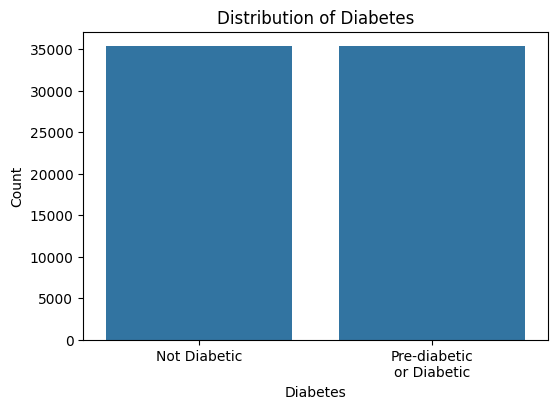

In [214]:
plt.figure(figsize=(6,4))

sns.countplot(x="Diabetes_binary", data=df_eda)
plt.title("Distribution of Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Diabetic", "Pre-diabetic\nor Diabetic"]
)
plt.show()

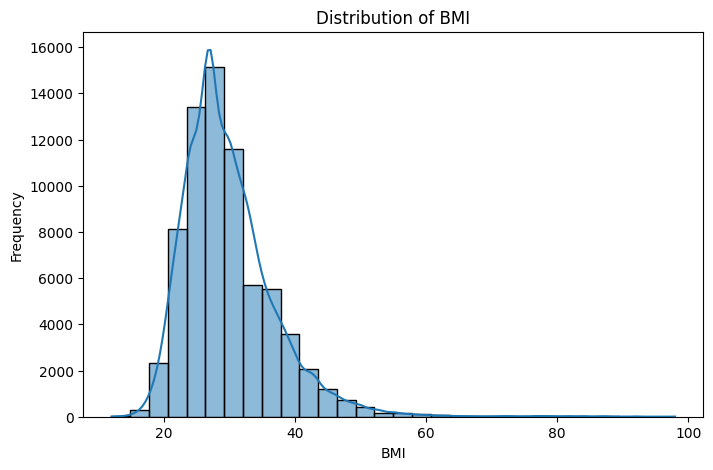

In [215]:
plt.figure(figsize=(8,5))

sns.histplot(df_eda["BMI"], bins=30, kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

There appear to be some high/extreme values in the BMI distribution — this is investigated further in the multivariate analysis (Section 4.4).

Distribution of binary lifestyle and health-indicator features:

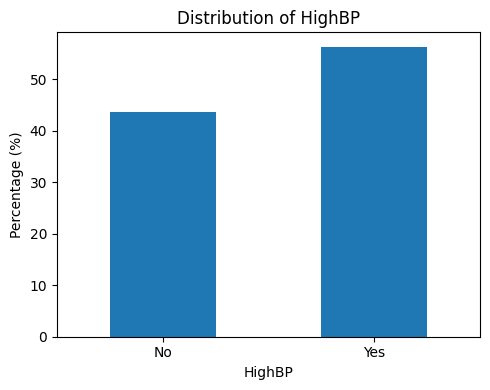

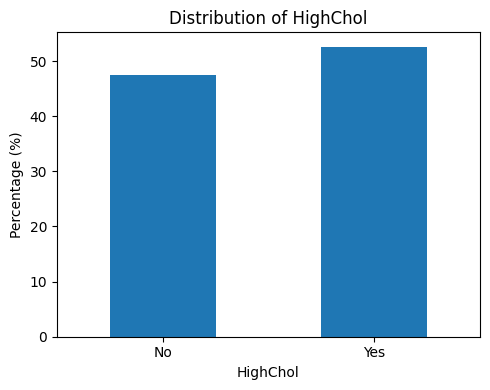

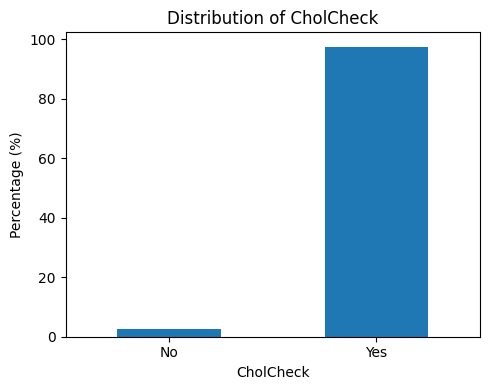

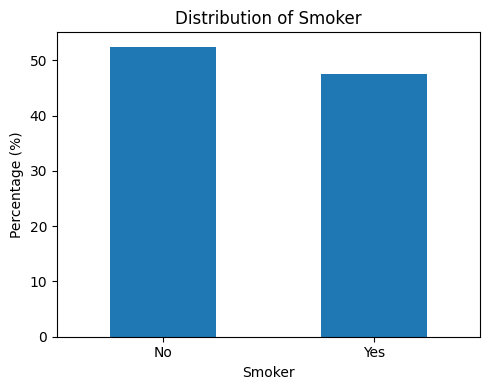

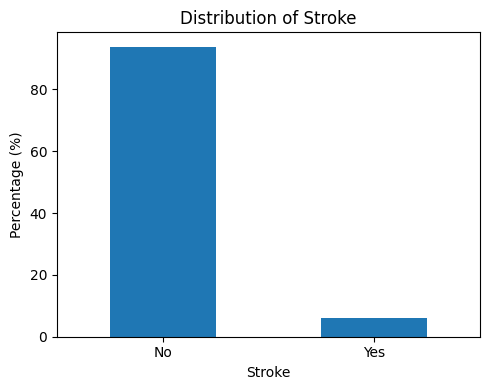

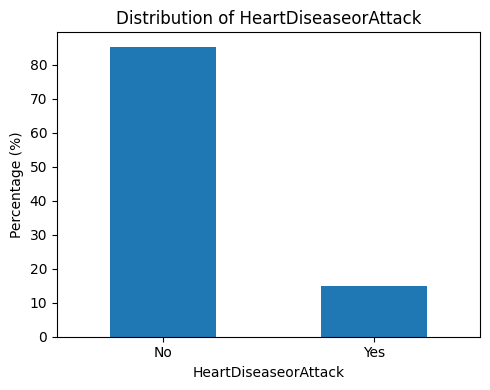

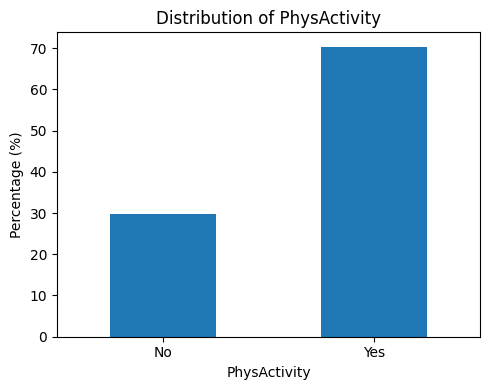

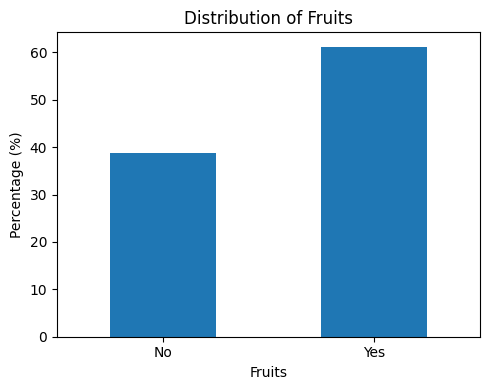

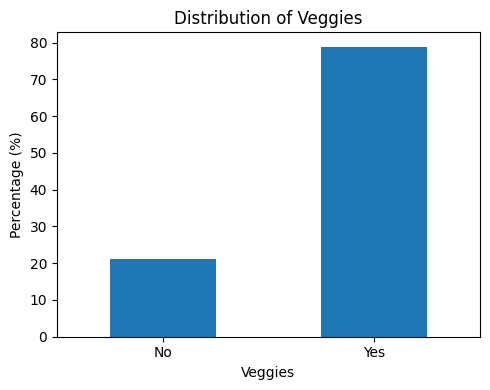

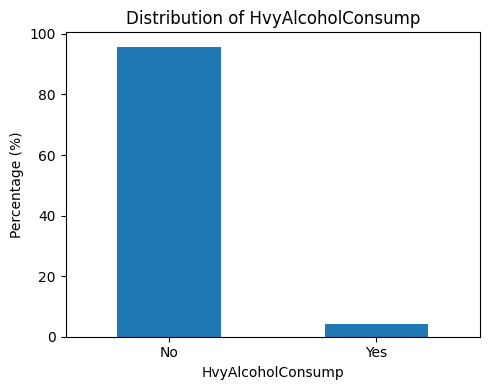

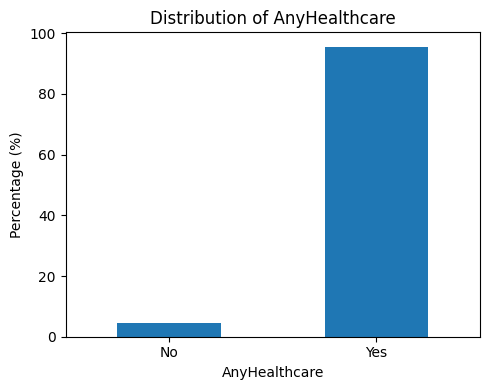

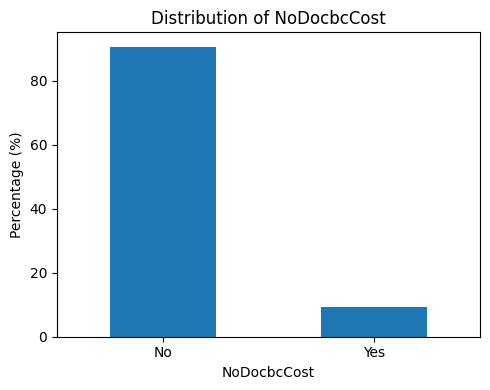

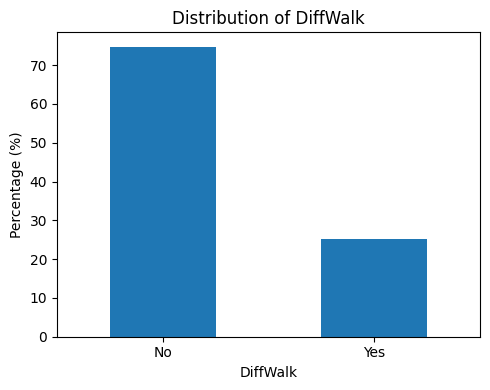

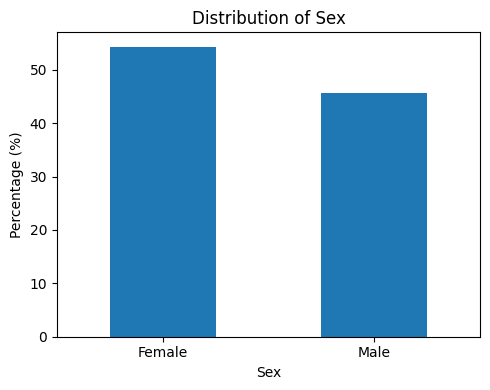

In [216]:
for feature in binary_features:

    percentages = (
        df[feature]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    percentages.index = percentages.index.map(binary_labels[feature])

    ax = percentages.plot(
        kind='bar',
        figsize=(5,4)
    )

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=0)
    plt.tight_layout()

    plt.show()

Distribution of ordinal features (age, education, income, general health. mental health):

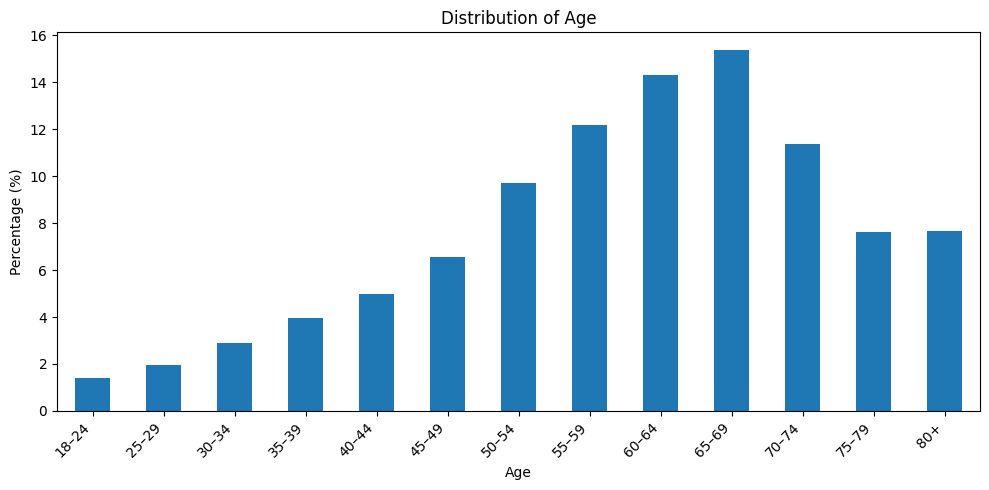

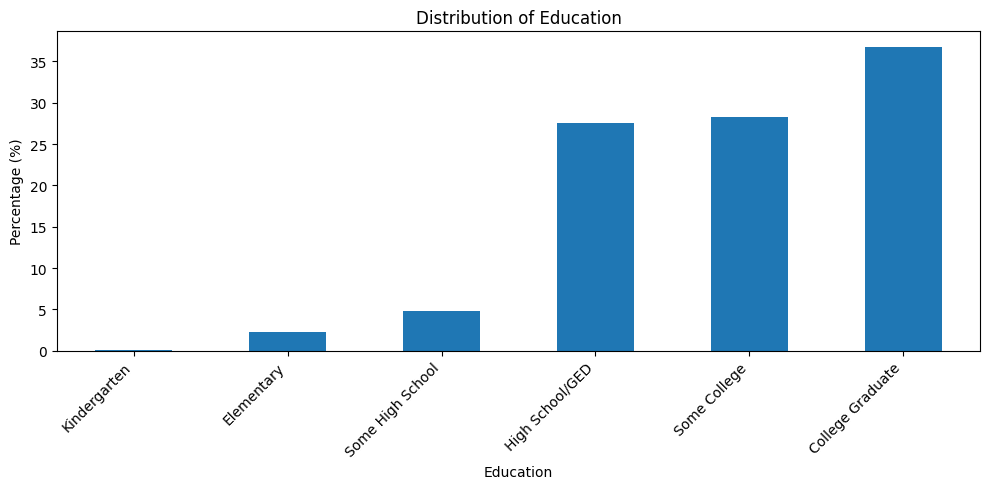

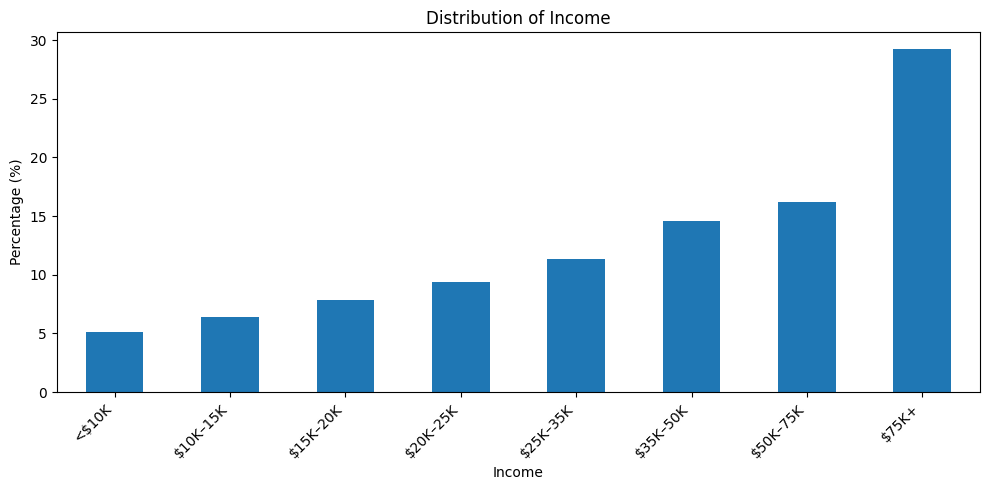

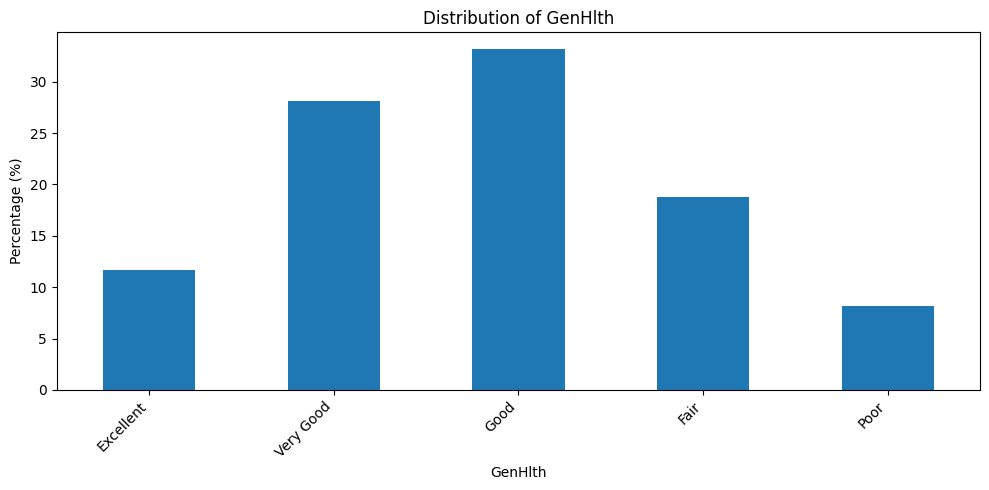

In [217]:
for feature in ordinal_features:

    percentages = (
        df_eda[feature]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    if feature == 'MentHlth' or feature == 'PhysHlth':
      continue

    percentages.index = percentages.index.map(ordinal_labels[feature])

    ax = percentages.plot(
        kind='bar',
        figsize=(10,5)
    )

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.show()

Distribution of categorical features (BMI_Class, PhysHlth_Group, MentHlth_Group):

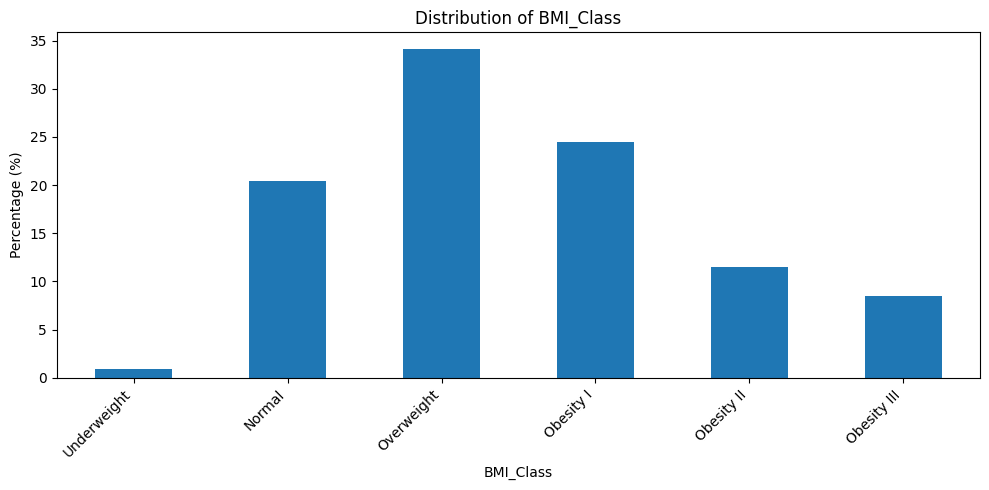

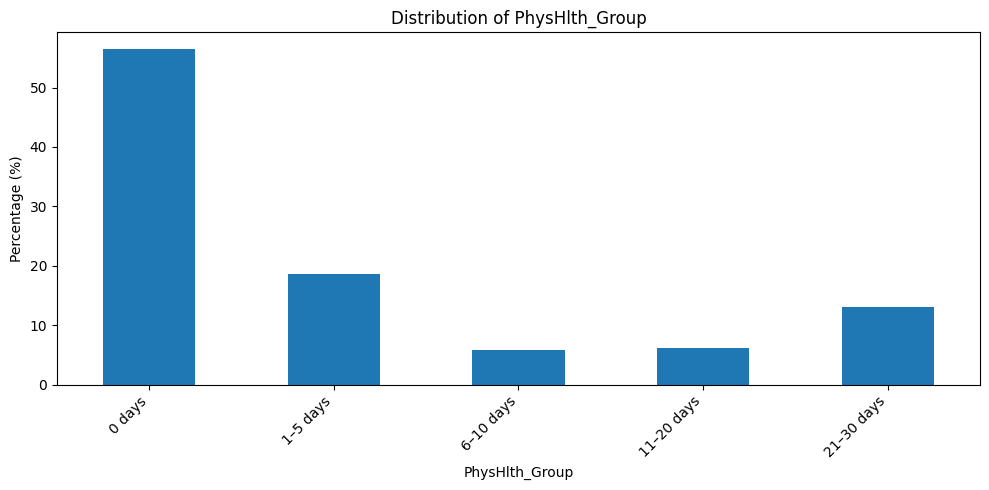

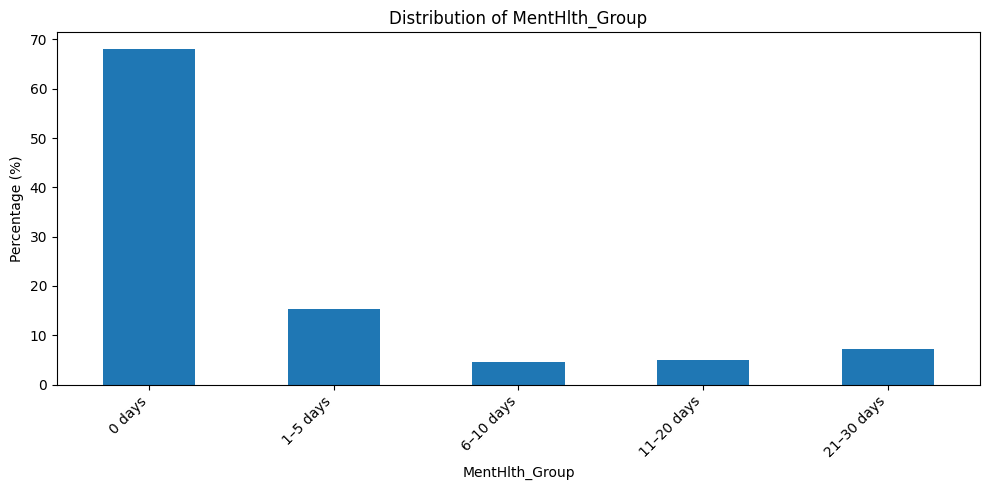

In [218]:
for feature in cat_features:

    percentages = (
        df_eda[feature]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    percentages = percentages.reindex(cat_feature_order[feature])

    ax = percentages.plot(
        kind='bar',
        figsize=(10,5)
    )

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.show()

### 5.2 Bivariate Analysis

Bivariate analysis for binary features against `Diabetes_binary`:

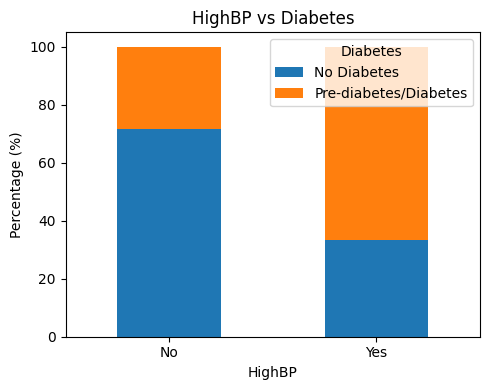

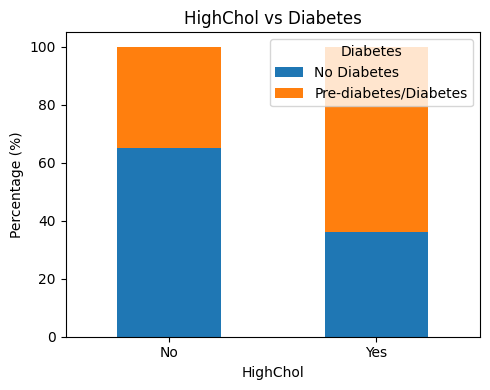

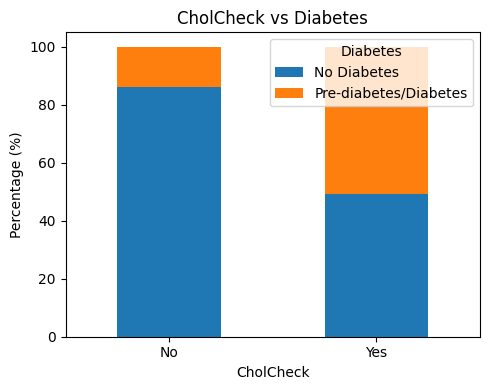

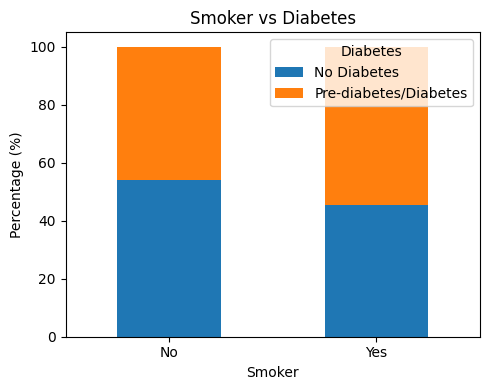

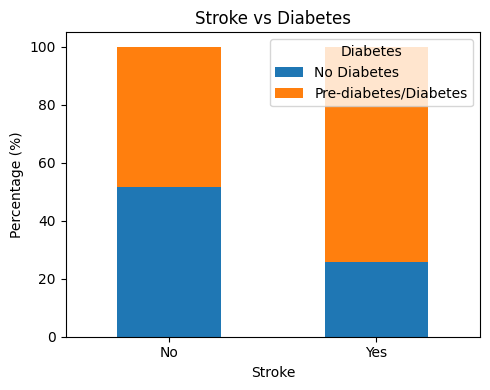

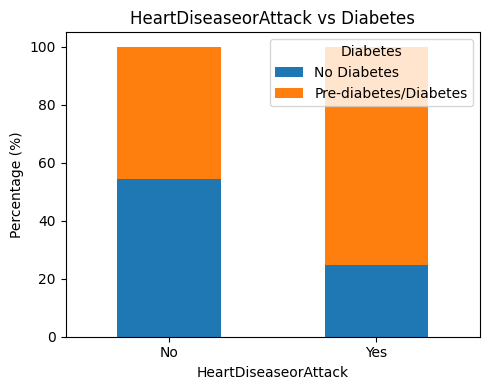

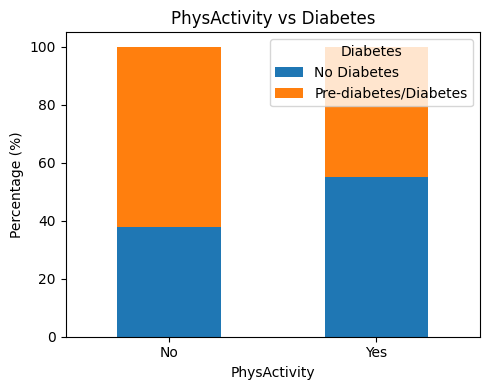

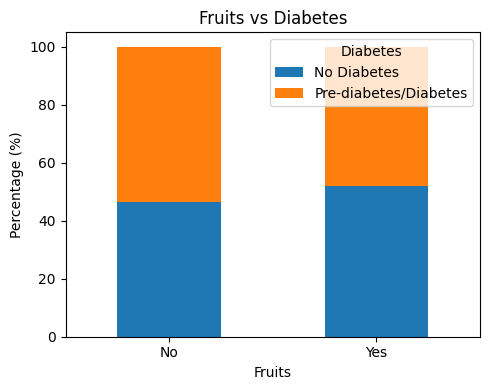

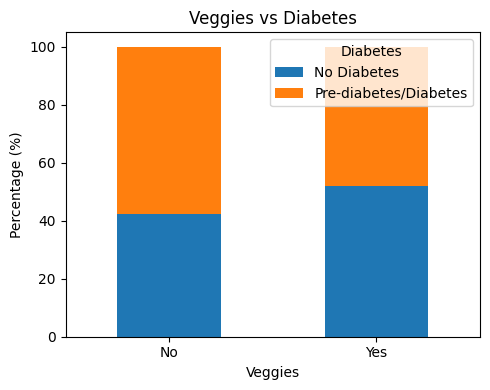

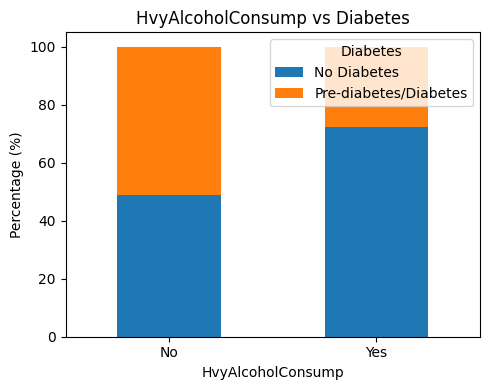

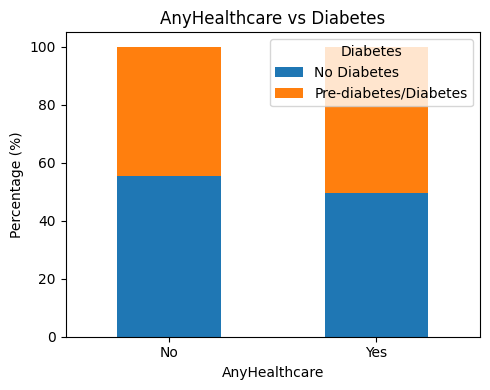

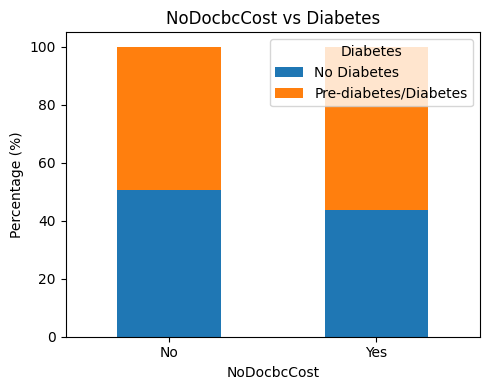

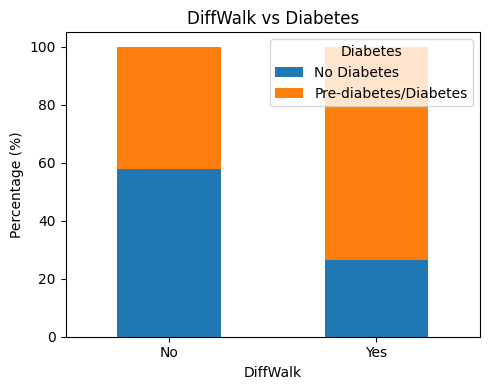

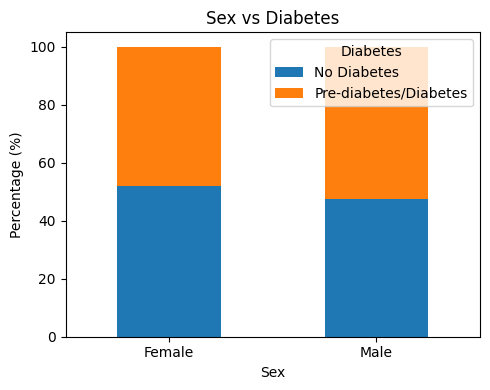

In [175]:
for feature in binary_features:

    table = pd.crosstab(
        df_eda[feature],
        df_eda['Diabetes_binary'],
        normalize='index'
    ) * 100

    table.index = table.index.map(binary_labels[feature])

    table.columns = ['No Diabetes', 'Pre-diabetes/Diabetes']

    table.plot(
        kind='bar',
        stacked=True,
        figsize=(5,4)
    )

    plt.title(f'{feature} vs Diabetes')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')
    plt.legend(title='Diabetes')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Bivariate analysis for ordinal features against `Diabetes_binary`:

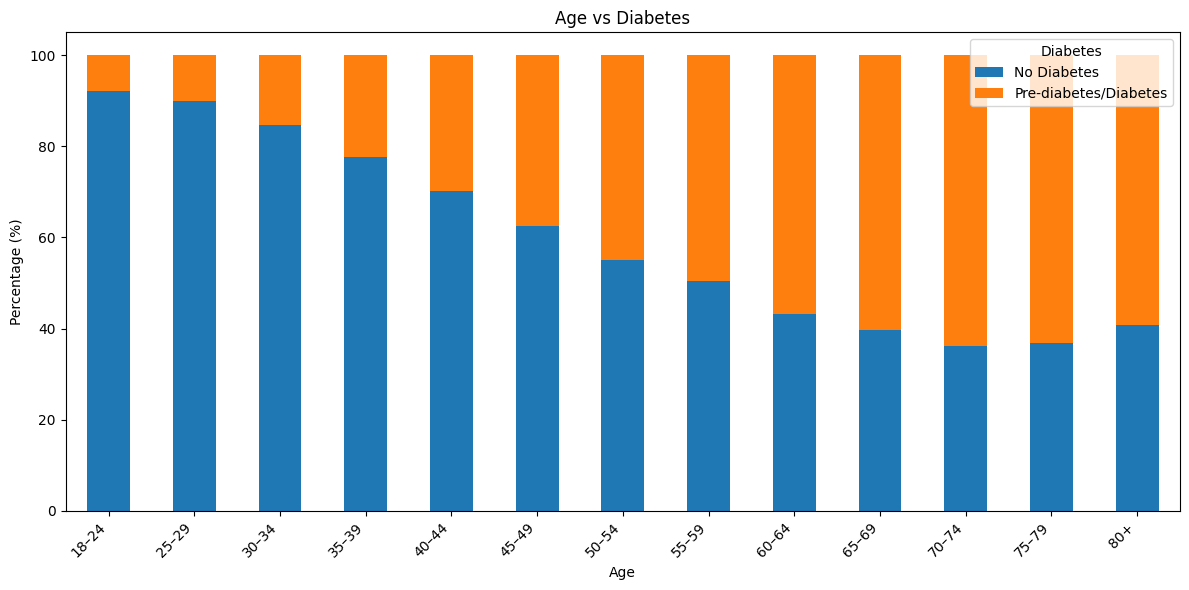

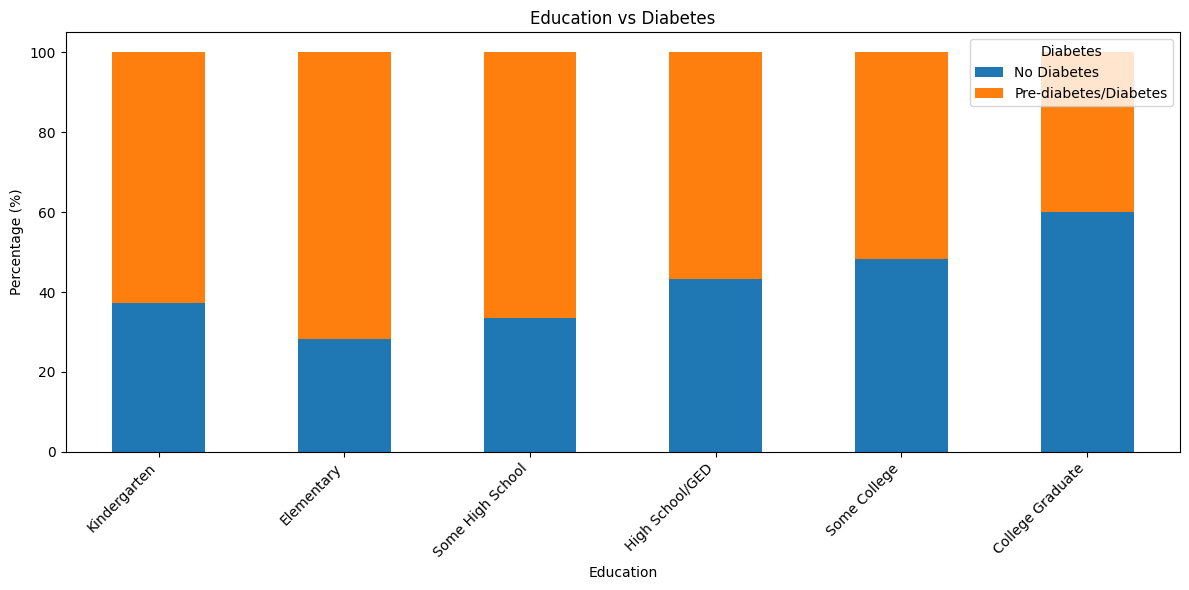

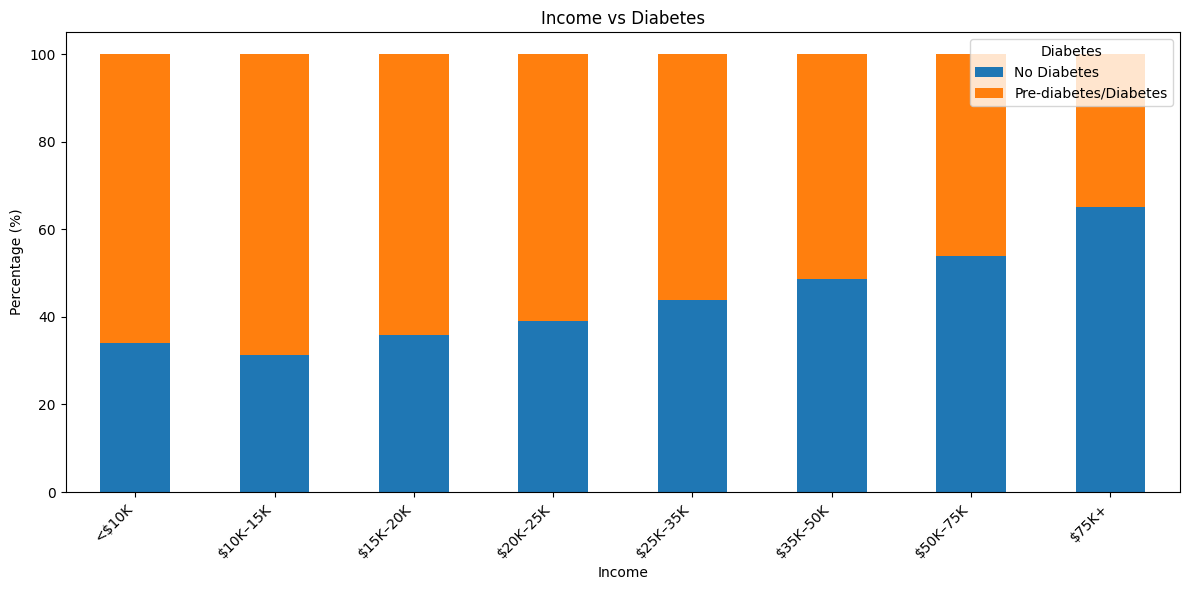

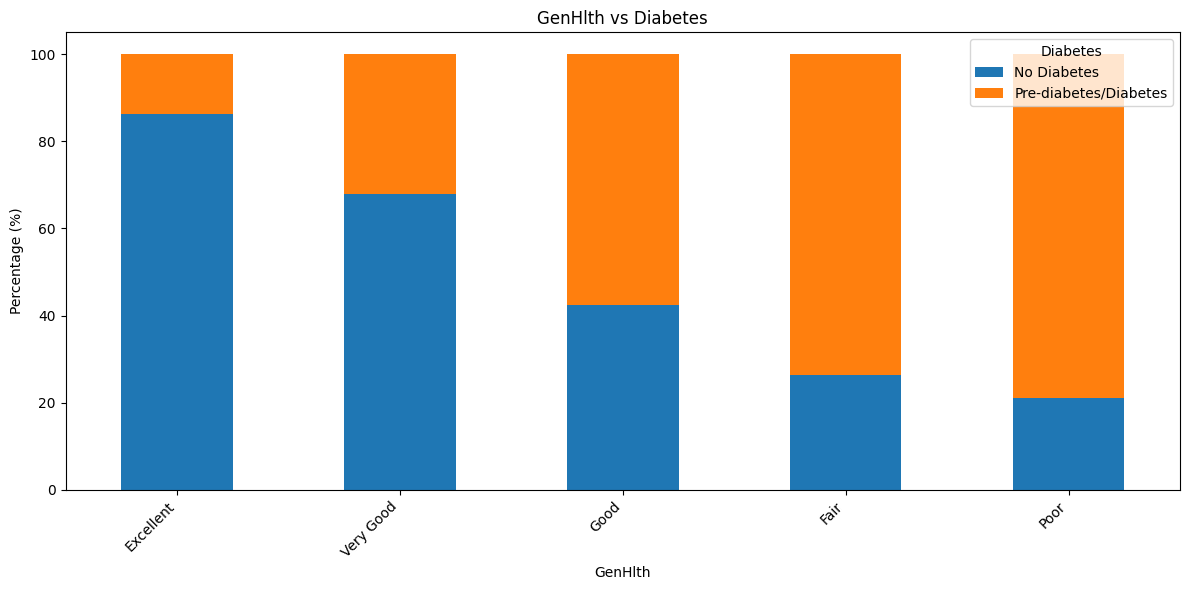

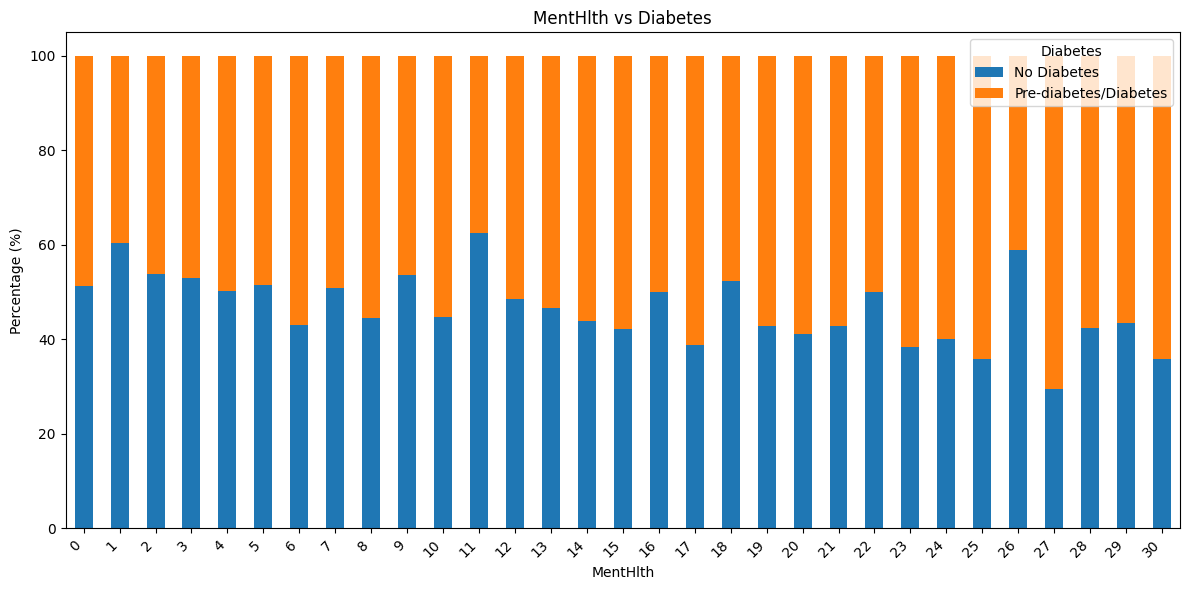

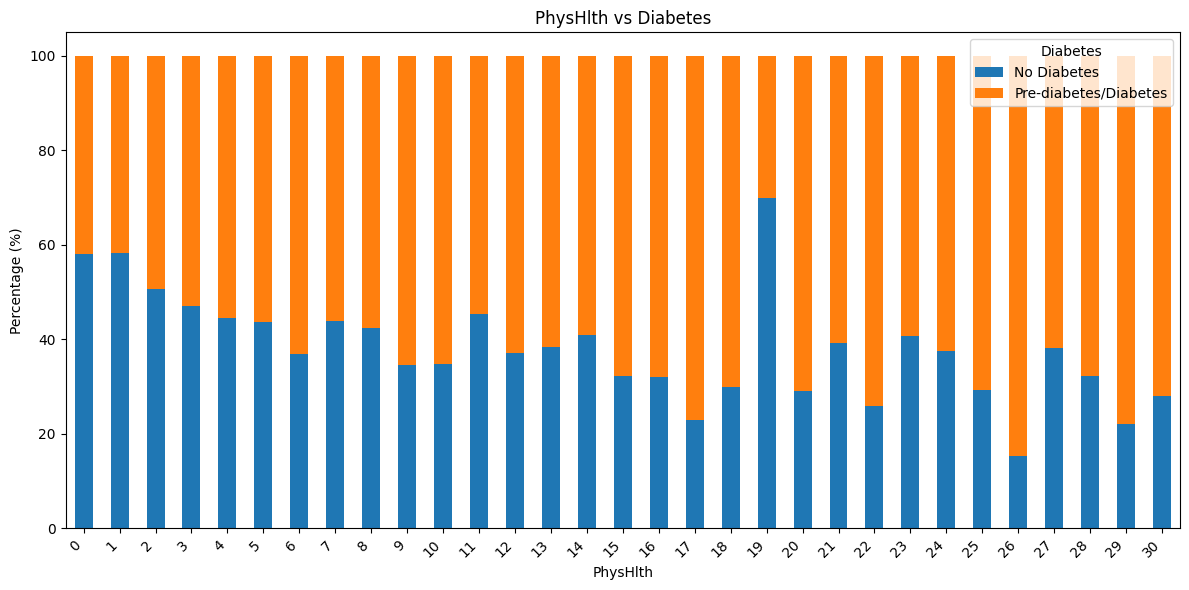

In [176]:
for feature in ordinal_features:

    table = pd.crosstab(
        df_eda[feature],
        df_eda['Diabetes_binary'],
        normalize='index'
    ) * 100

    table.columns = ['No Diabetes', 'Pre-diabetes/Diabetes']

    # Replace numeric values with labels
    if feature in ordinal_labels:
        table.index = table.index.map(ordinal_labels[feature])

    ax = table.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6)
    )

    plt.title(f'{feature} vs Diabetes')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')
    plt.legend(title='Diabetes')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Bivariate analysis for categorical features against `Diabetes_binary`:

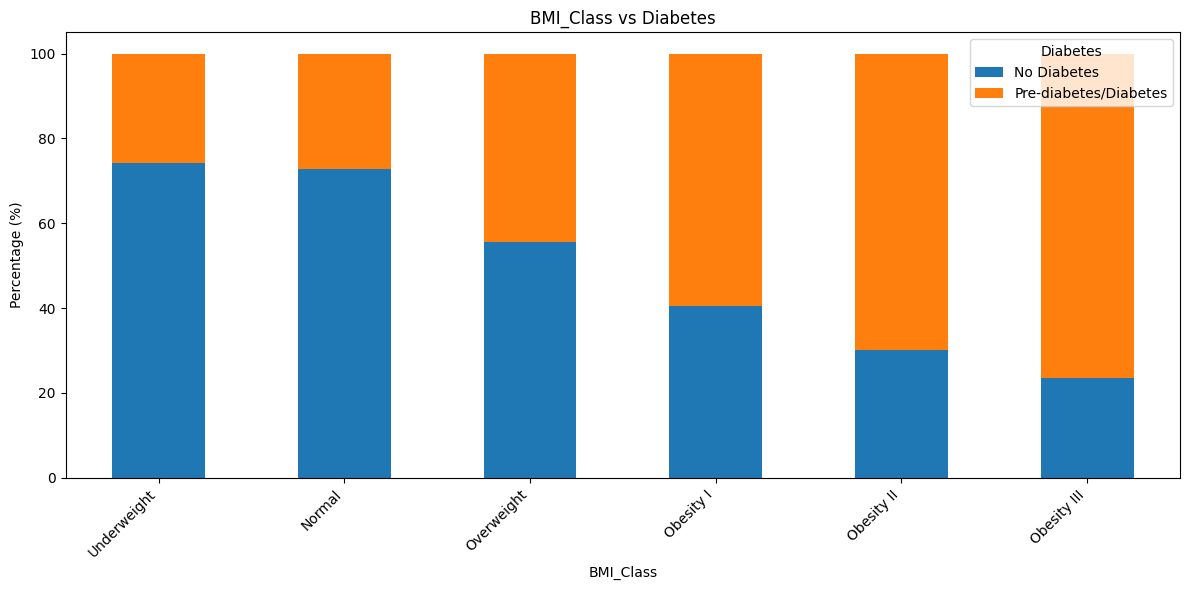

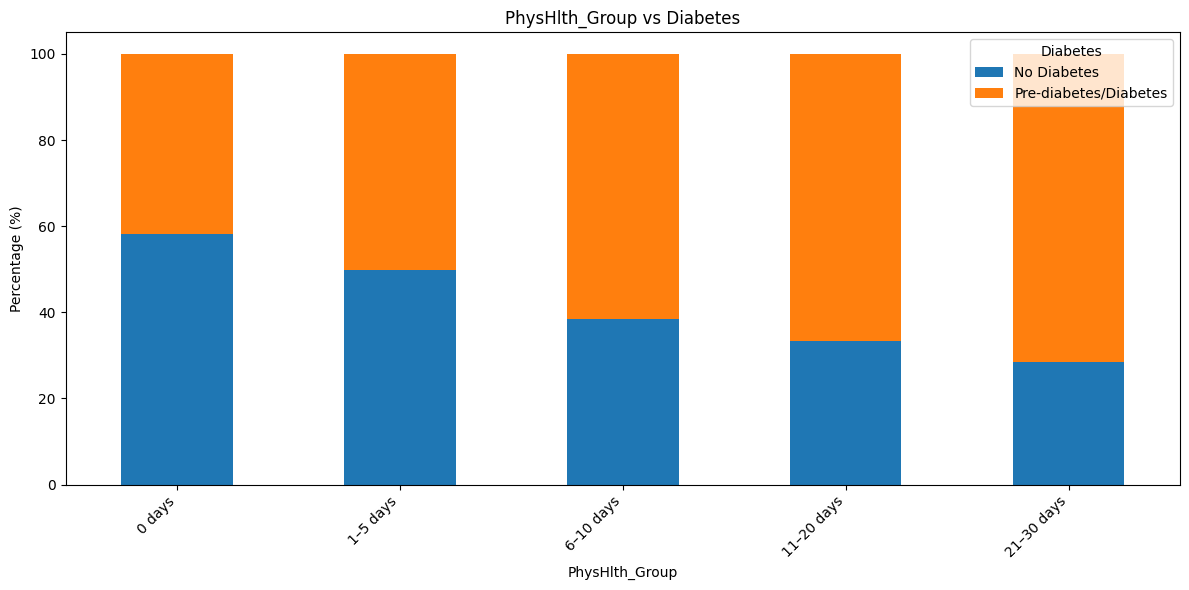

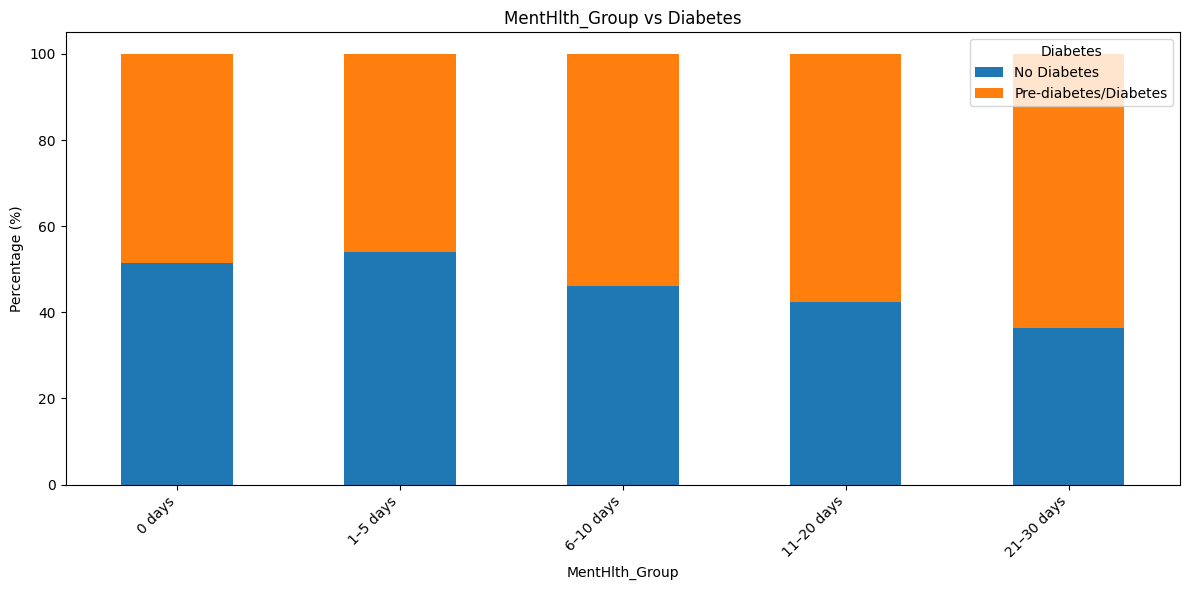

In [177]:
for feature in cat_features:

    table = pd.crosstab(
        df_eda[feature],
        df_eda['Diabetes_binary'],
        normalize='index'
    ) * 100

    table.columns = ['No Diabetes', 'Pre-diabetes/Diabetes']

    ax = table.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6)
    )

    plt.title(f'{feature} vs Diabetes')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')
    plt.legend(title='Diabetes')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Since `MentHlth` and `PhysHlth` are discrete numerical (count) variables rather than categorical ones, a box plot is more appropriate than a bar chart here:

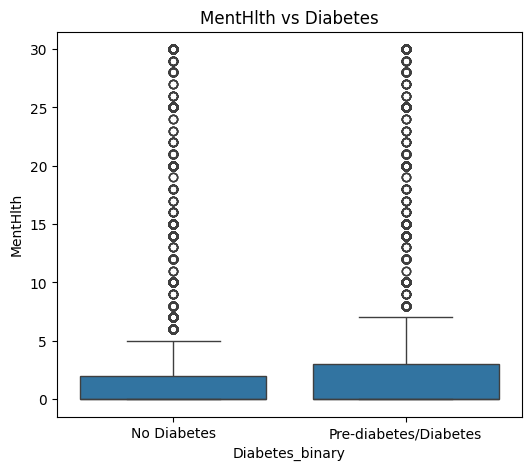

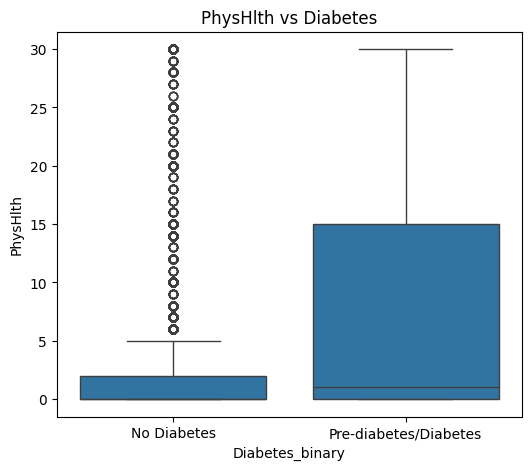

In [178]:
health_days = ['MentHlth', 'PhysHlth']

for feature in health_days:

    plt.figure(figsize=(6,5))

    sns.boxplot(
        data=df,
        x='Diabetes_binary',
        y=feature
    )

    plt.xticks(
        [0,1],
        ['No Diabetes','Pre-diabetes/Diabetes']
    )

    plt.title(f'{feature} vs Diabetes')

    plt.show()

Diabetic patients across BMI classes:

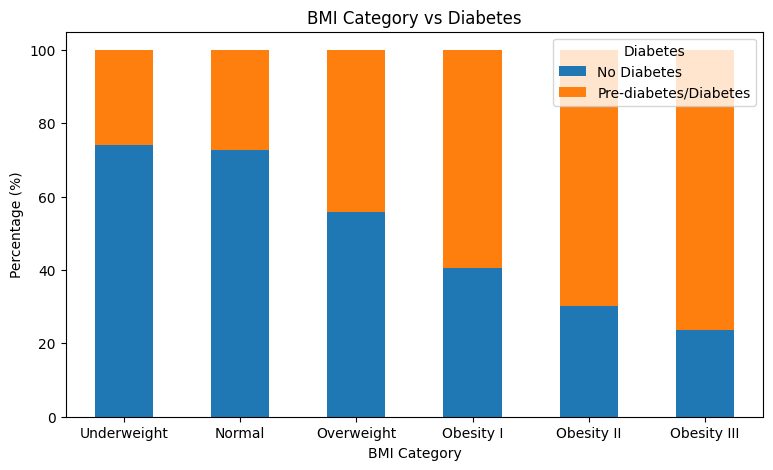

In [179]:
table = pd.crosstab(
    df_eda['BMI_Class'],
    df_eda['Diabetes_binary'],
    normalize='index'
) * 100

table.columns = ['No Diabetes','Pre-diabetes/Diabetes']

table.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5)
)

plt.title('BMI Category vs Diabetes')
plt.ylabel('Percentage (%)')
plt.xlabel('BMI Category')
plt.legend(title='Diabetes')
plt.xticks(rotation=0)

plt.show()

### 5.3 Multivariate Analysis

Correlation Heatmap

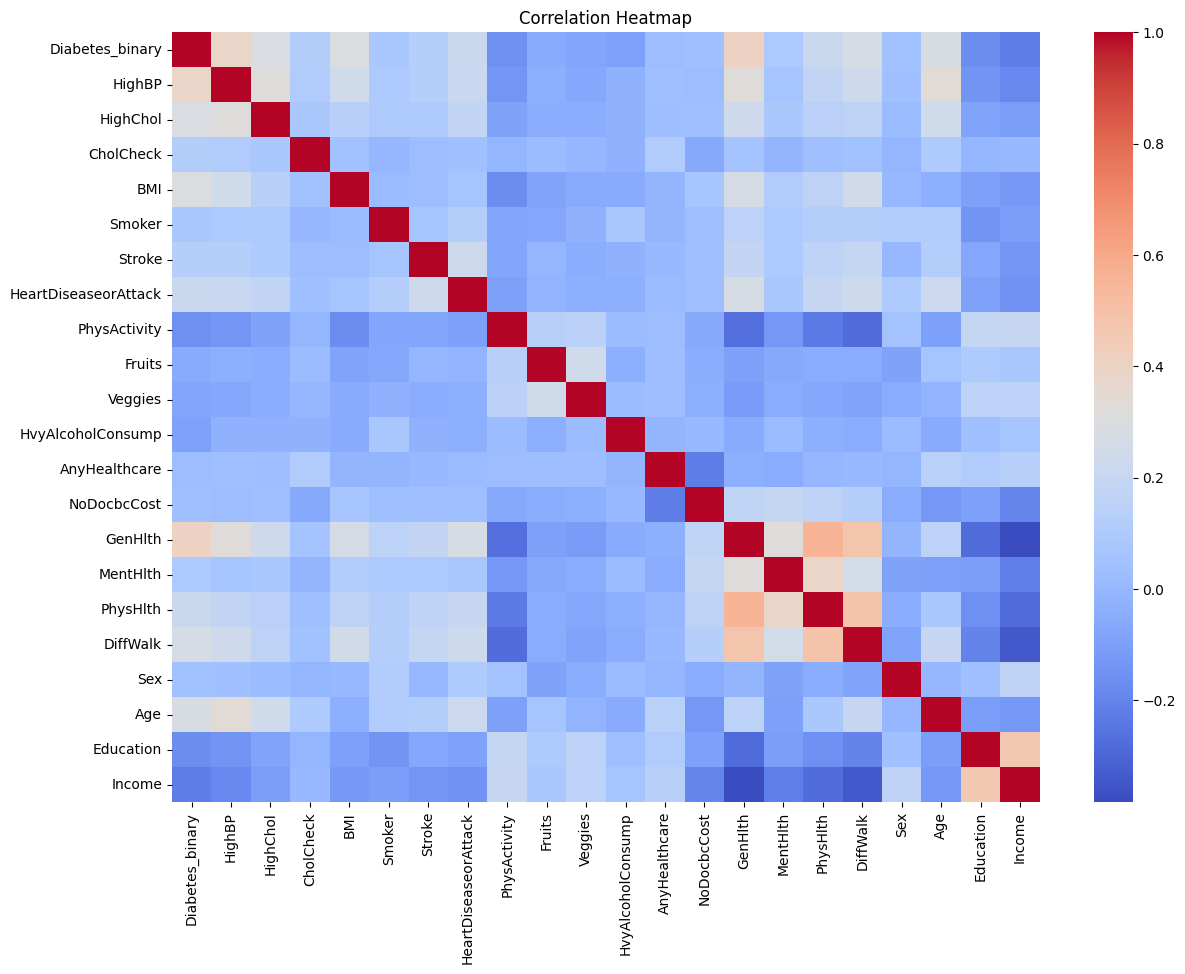

In [180]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Physical activity vs. diabetes, split by sex:

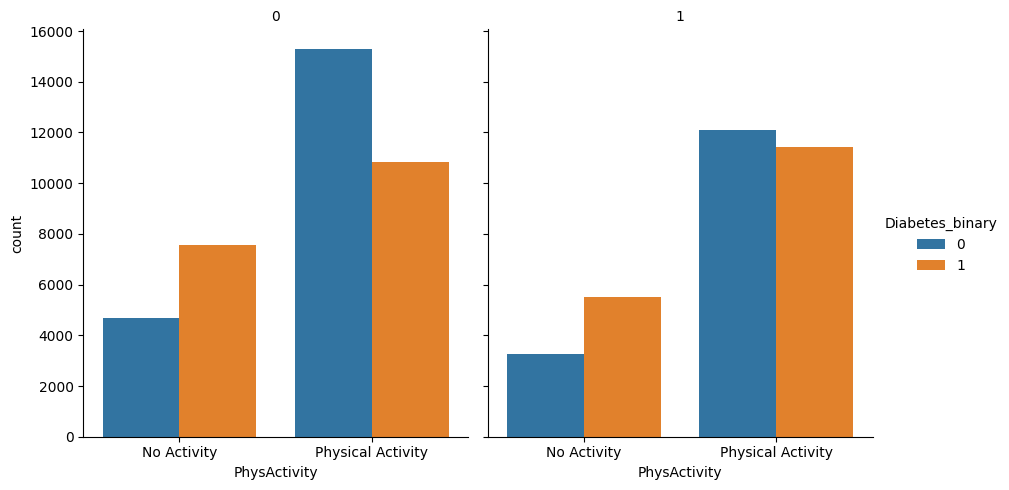

In [181]:
g = sns.catplot(
    data=df_eda,
    x='PhysActivity',
    hue='Diabetes_binary',
    col='Sex',
    kind='count',
    height=5,
    aspect=0.9
)

g.set_xticklabels(['No Activity','Physical Activity'])
g.set_titles("Female" if "{col_name}"=="0.0" else "{col_name}")

BMI distribution across age groups, split by diabetes status:

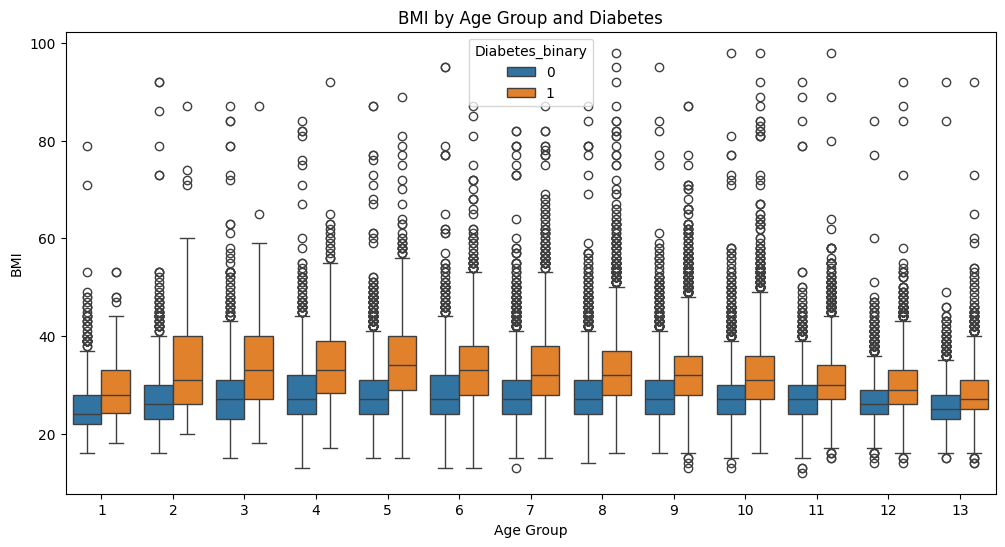

In [182]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_eda,
    x='Age',
    y='BMI',
    hue='Diabetes_binary'
)

plt.title("BMI by Age Group and Diabetes")
plt.xlabel("Age Group")
plt.ylabel("BMI")

plt.show()

General health rating vs. diabetes:

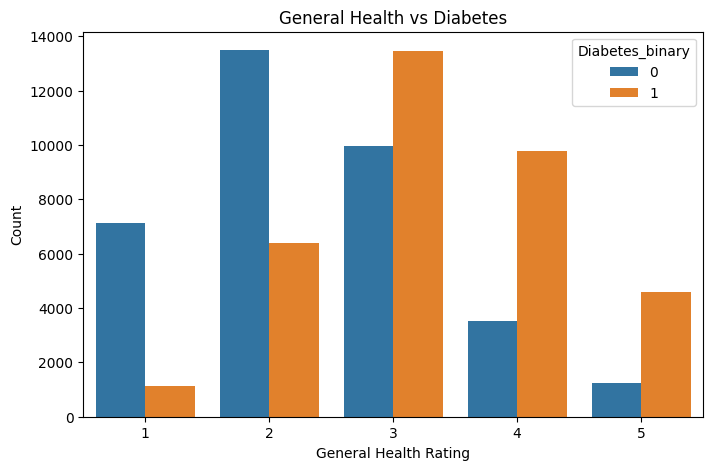

In [183]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_eda,
    x='GenHlth',
    hue='Diabetes_binary'
)

plt.xlabel("General Health Rating")
plt.ylabel("Count")
plt.title("General Health vs Diabetes")

plt.show()

General health rating vs. diabetes, split by sex:

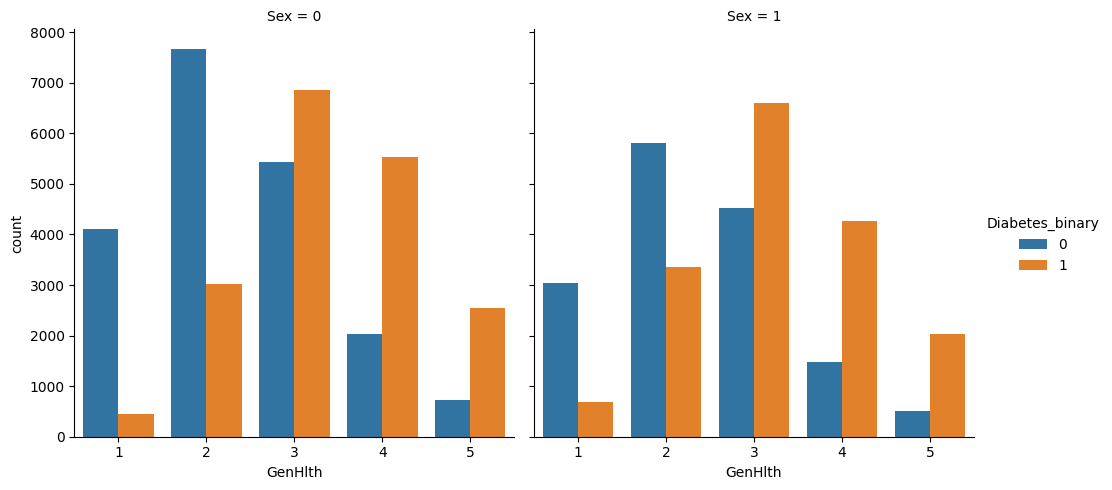

In [184]:
sns.catplot(
    data=df_eda,
    x='GenHlth',
    hue='Diabetes_binary',
    col='Sex',
    kind='count'
)

BMI vs. mental health days, colored by diabetes status:

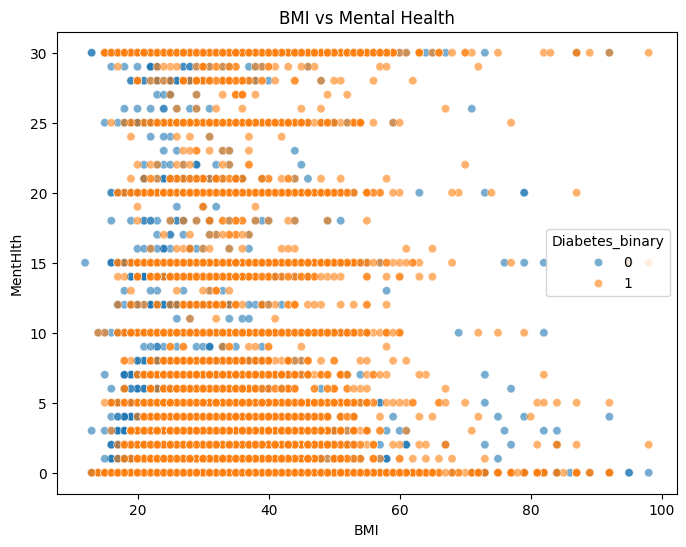

In [185]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='BMI',
    y='MentHlth',
    hue='Diabetes_binary',
    alpha=0.6
)

plt.title("BMI vs Mental Health")
plt.show()

BMI distribution split by sex and diabetes status:

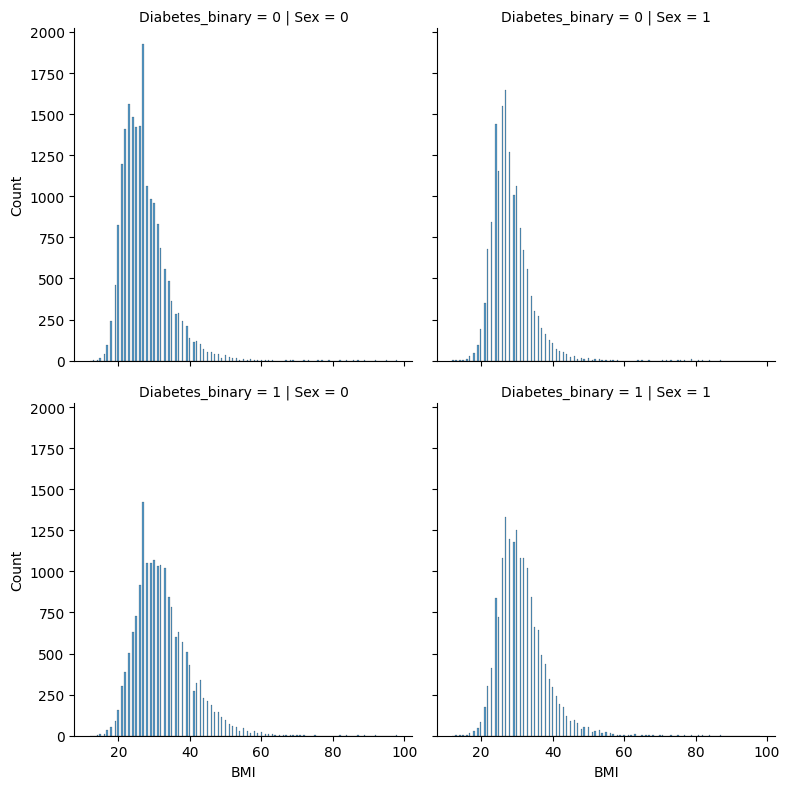

In [186]:
sns.displot(
    data=df,
    x='BMI',
    col='Sex',
    row='Diabetes_binary',
    height=4
)

Average BMI by age group and diabetes status:

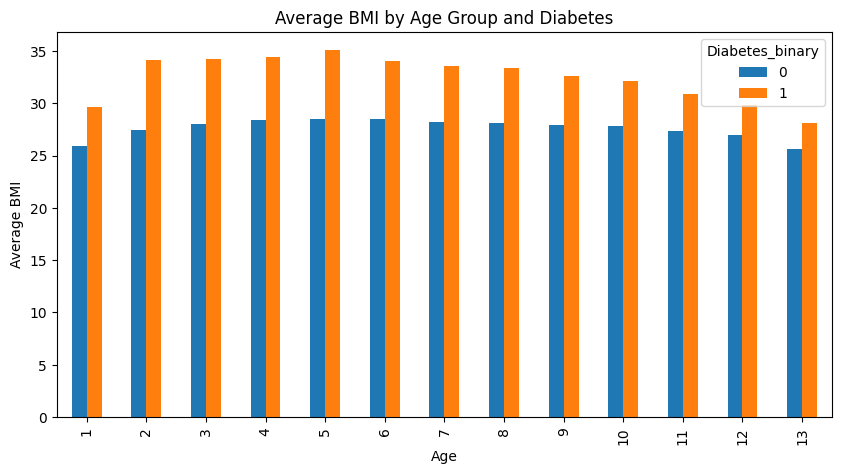

In [187]:
pivot = df.pivot_table(
    values='BMI',
    index='Age',
    columns='Diabetes_binary',
    aggfunc='mean'
)

pivot.plot(kind='bar', figsize=(10,5))
plt.ylabel("Average BMI")
plt.title("Average BMI by Age Group and Diabetes")
plt.show()

### 5.4 Anomaly in BMI??

Checking whether the high-BMI values behave consistently with other diabetes risk factors (age, general health, heart disease, difficulty walking, physical activity) — if so, they are likely genuine severe-obesity cases rather than data errors:

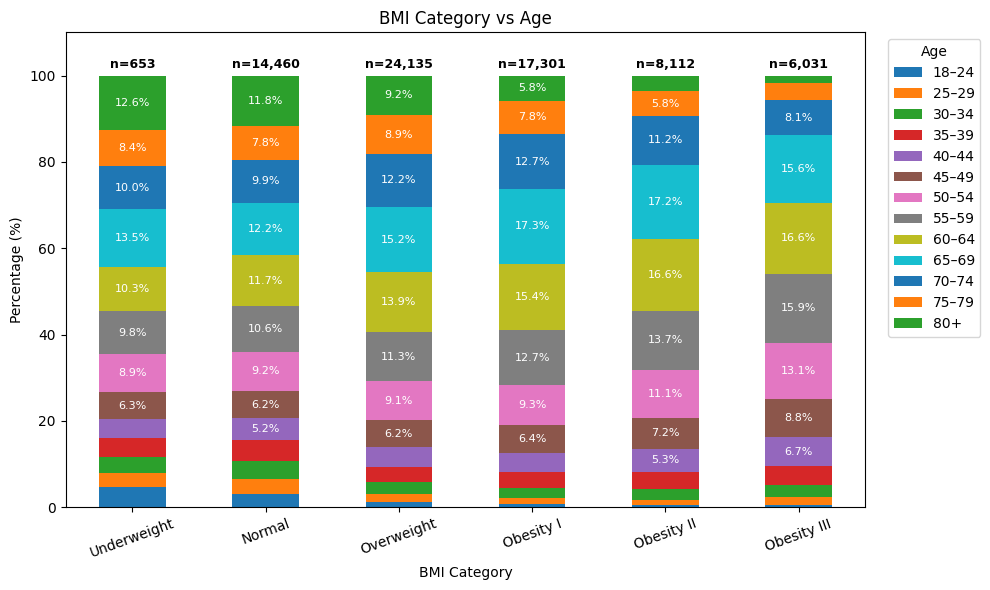

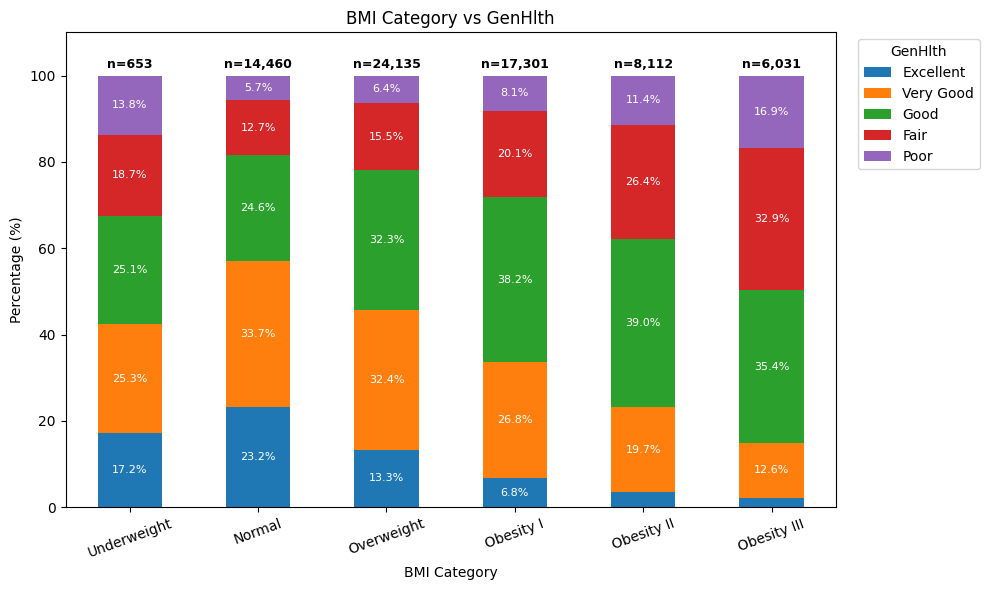

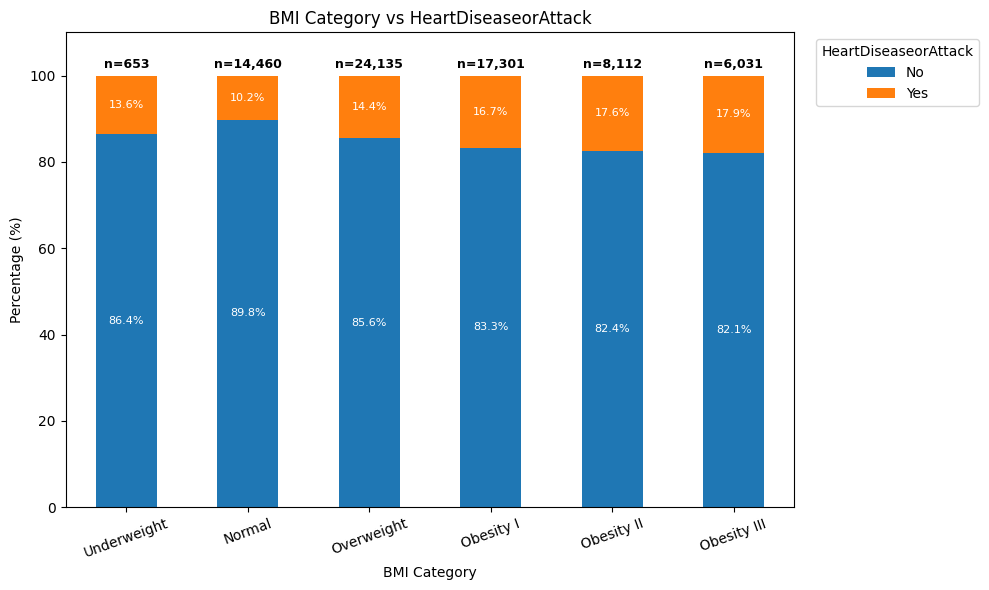

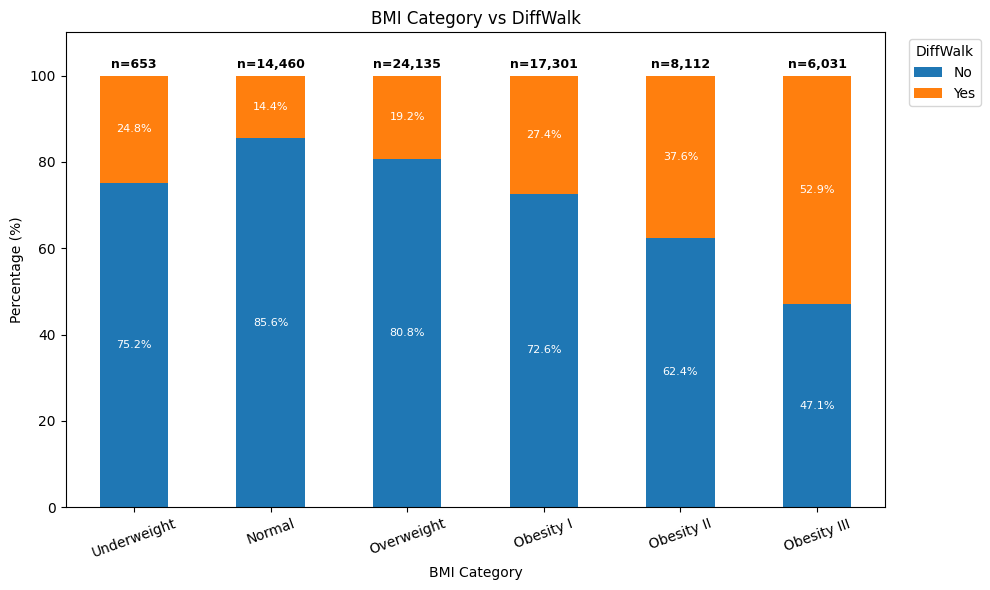

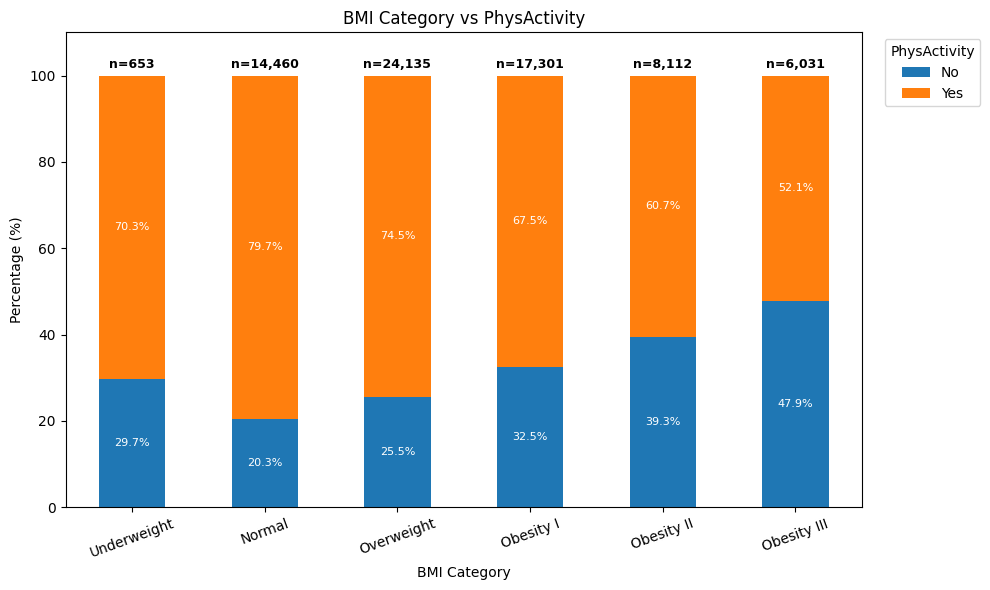

In [188]:
features = [
    'Age',
    'GenHlth',
    'HeartDiseaseorAttack',
    'DiffWalk',
    'PhysActivity'
]

feature_labels = {
    'Age': ordinal_labels['Age'],
    'GenHlth': ordinal_labels['GenHlth'],
    'HeartDiseaseorAttack': binary_labels['HeartDiseaseorAttack'],
    'DiffWalk': binary_labels['DiffWalk'],
    'PhysActivity': binary_labels['PhysActivity'],
}



for feature in features:

    table = pd.crosstab(
        df_eda['BMI_Class'],
        df_eda[feature],
        normalize='index'
    ) * 100

    table = table.reindex(bmi_order)

    # Replace numeric column labels with descriptive labels
    table.columns = [feature_labels[feature][c] for c in table.columns]

    ax = table.plot(
        kind='bar',
        stacked=True,
        figsize=(10,6)
    )

    # -------------------------
    # Percentage labels
    # -------------------------
    for container in ax.containers:

        labels = [
            f'{bar.get_height():.1f}%'
            if bar.get_height() >= 5 else ''
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=8,
            color='white'
        )

    # -------------------------
    # Counts above each BMI class
    # -------------------------
    counts = (
        df_eda['BMI_Class']
        .value_counts()
        .reindex(bmi_order)
    )

    for i, count in enumerate(counts):
        ax.text(
            i,
            101,
            f'n={count:,}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_ylim(0,110)

    plt.title(f'BMI Category vs {feature}')
    plt.xlabel('BMI Category')
    plt.ylabel('Percentage (%)')
    plt.legend(
        title=feature,
        bbox_to_anchor=(1.02,1),
        loc='upper left'
    )

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

Comparing the BMI–diabetes relationship separately for people with and without difficulty walking, to see if the pattern holds within each group:

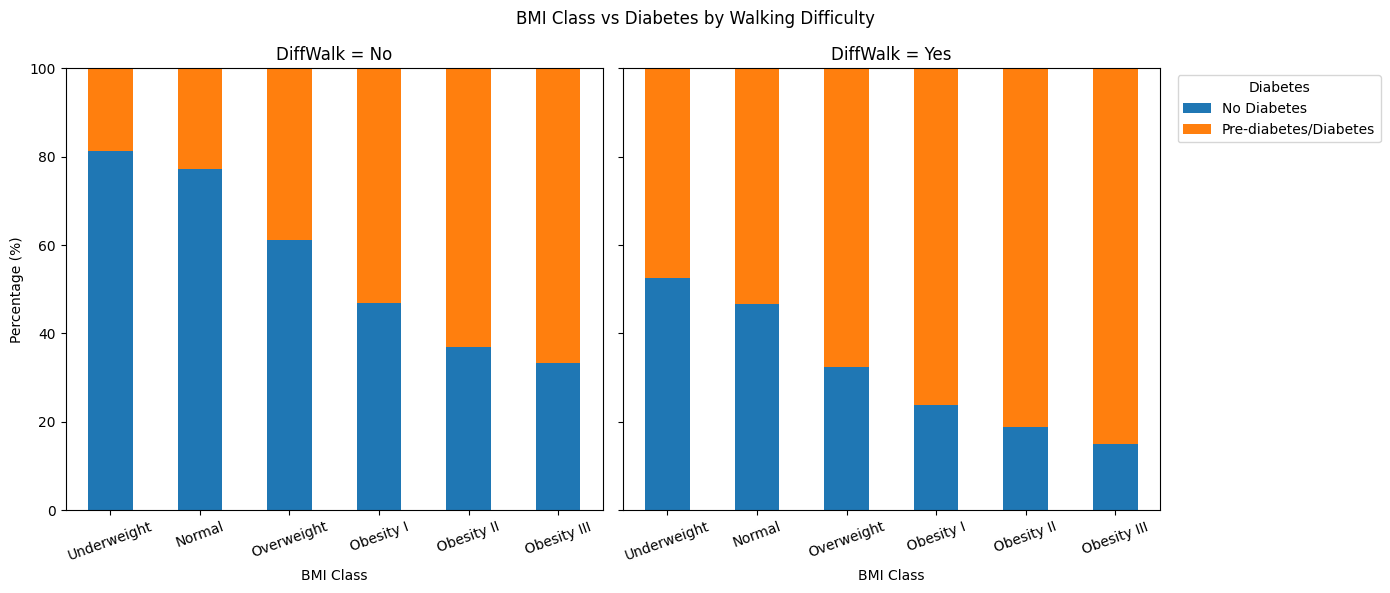

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, diff in enumerate([0, 1]):

    subset = df_eda[df_eda['DiffWalk'] == diff]

    table = pd.crosstab(
        subset['BMI_Class'],
        subset['Diabetes_binary'],
        normalize='index'
    ) * 100

    table = table.reindex(bmi_order)
    table.columns = ['No Diabetes', 'Pre-diabetes/Diabetes']

    table.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(
        f"DiffWalk = {'No' if diff == 0 else 'Yes'}"
    )
    axes[i].set_xlabel('BMI Class')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=20)

axes[1].legend(
    title='Diabetes',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.suptitle('BMI Class vs Diabetes by Walking Difficulty')
plt.tight_layout()
plt.show()

Relationship between BMI category and heart disease/attack history:

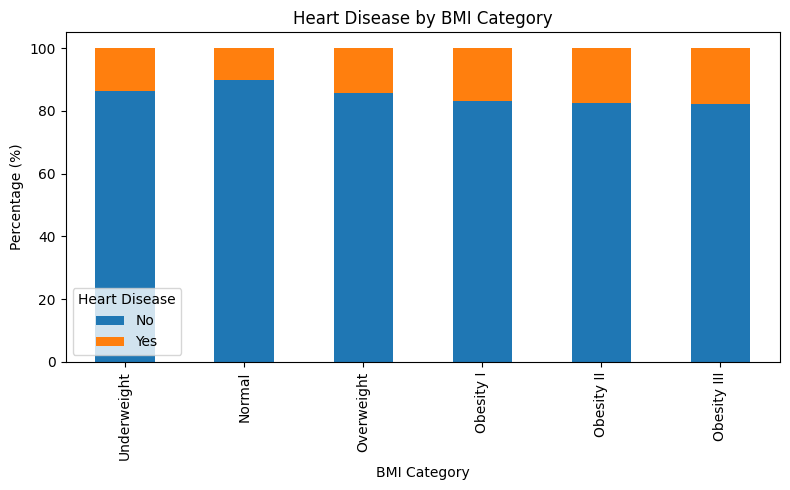

In [190]:
table = pd.crosstab(
    df_eda['BMI_Class'],
    df_eda['HeartDiseaseorAttack'],
    normalize='index'
) * 100

table.columns = ['No','Yes']

table.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Heart Disease by BMI Category')
plt.ylabel('Percentage (%)')
plt.xlabel('BMI Category')
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

## 6. Data Preprocessing

### 6.1 Outlier Handling

A boxplot identified extreme values in the BMI feature. These observations were further investigated through univariate, bivariate, and multivariate analyses. The extreme BMI values were found to exhibit meaningful relationships with diabetes prevalence, general health, physical activity, heart disease, and walking difficulty, indicating that they represent genuine cases of severe obesity rather than data entry errors. Since BMI is a clinically significant predictor of diabetes, these observations were retained. No outlier treatment was applied. The remaining numerical variables (MentHlth and PhysHlth) are bounded count variables, and Age is an ordinal categorical feature; therefore, no outlier handling was required for these variables.

### 6.2 Feature and Target Separation

In [219]:
#separate features and target
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

Confirm the shapes of the separated features (`X`) and target (`y`):

In [220]:
print(X.shape)
print(y.shape)

(70692, 21)
(70692,)


### 6.3 Train-Test Split

In [221]:
#train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 6.4 Scaling

Feature scaling was applied to the numeric measurement and count variables (BMI, MentHlth, and PhysHlth) using StandardScaler. These variables have different numerical ranges, and scaling helps distance-based and gradient-based machine learning algorithms perform more effectively. Binary and ordinal categorical variables were left unchanged because they represent encoded categories rather than continuous measurements.

In [222]:
from sklearn.preprocessing import StandardScaler

# Create a scaler
scaler = StandardScaler()

# Make a copy of the features
X_scaled = X.copy()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale only continuous numerical columns
columns_to_scale = ["BMI", "MentHlth", "PhysHlth"]

X_train_scaled[columns_to_scale] = scaler.fit_transform(
    X_train_scaled[columns_to_scale]
)

X_test_scaled[columns_to_scale] = scaler.transform(
    X_test_scaled[columns_to_scale]
)

Preview of the scaled training data:

In [223]:
X_train.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
47977,1,0,1,29,1,0,0,1,1,1,...,1,0,2,0,0,0,1,10,6,8
2676,0,1,1,24,1,0,0,1,0,1,...,1,0,3,15,6,0,0,7,5,1
35637,1,0,1,42,1,0,0,1,1,1,...,1,0,3,0,10,1,0,11,5,4
52420,1,1,1,30,0,0,1,1,1,1,...,1,0,3,0,1,0,0,10,5,5
12445,1,0,1,35,1,0,0,1,1,1,...,1,0,3,0,0,0,1,6,4,5


### 6.5 Feature Selection

##### 6.5.1 Correlation Analysis

**Correlation analysis is skipped** for feature selection, since the EDA did not reveal any strongly correlated feature pairs.

##### 6.5.2 Mutual Information

Instead of correlation analysis, feature relevance is assessed using **Mutual Information**, which can also capture non-linear relationships between each feature and the target. This is fit on `X_train`/`y_train` only (not the full dataset) to avoid leaking information from the test set into the feature-selection step.

In [224]:
from sklearn.feature_selection import mutual_info_classif


mi = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = (
    pd.DataFrame({
        "Feature": X.columns,
        "Mutual Information": mi
    })
    .sort_values("Mutual Information", ascending=False)
)

mi_scores

,Feature,Mutual Information
13,GenHlth,0.093949
0,HighBP,0.083612
3,BMI,0.058403
18,Age,0.045789
1,HighChol,0.045053
16,DiffWalk,0.040397
15,PhysHlth,0.027660
6,HeartDiseaseorAttack,0.025650
20,Income,0.025170
7,PhysActivity,0.019485


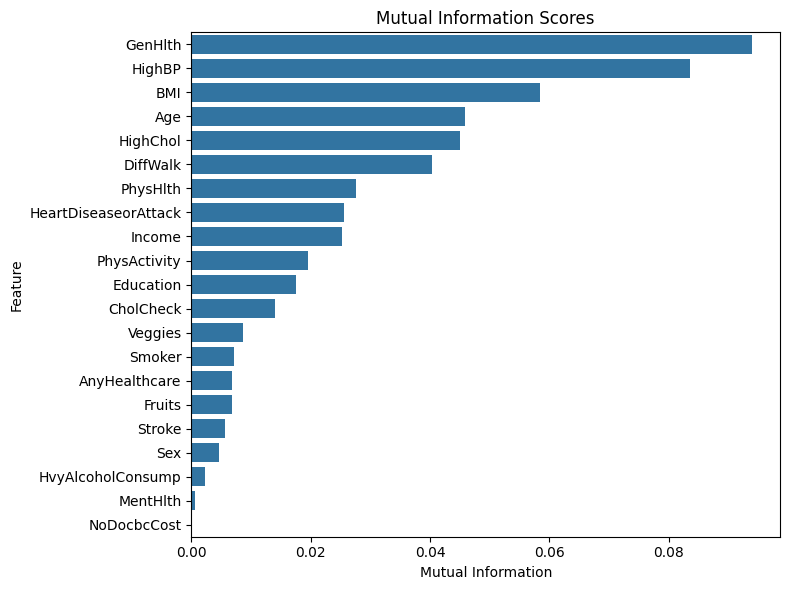

In [225]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=mi_scores,
    x="Mutual Information",
    y="Feature"
)

plt.title("Mutual Information Scores")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

`GenHlth`, `HighBP`, and `BMI` come out as the strongest individual predictors of diabetes by mutual information, while `NoDocbcCost` contributes virtually no information on its own. This broadly agrees with the patterns seen during EDA and can guide later feature-selection decisions.

##### 6.5.3 Using SelectKBest

To formalize the ranking from the Mutual Information analysis above into an actual feature-selection step, we use scikit-learn's `SelectKBest`. It scores every feature independently and keeps only the top `k`.

This is fit on `X_train`/`y_train` only (not the full dataset) to avoid leaking information from the test set into the feature-selection step.

In [226]:
from sklearn.feature_selection import SelectKBest, f_classif

k = 18  # number of top features to keep

selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train, y_train)

kbest_scores = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "F-Score": selector.scores_,
        "P-value": selector.pvalues_
    })
    .sort_values("F-Score", ascending=False)
)

kbest_scores

,Feature,F-Score,P-value
13,GenHlth,11441.080616,0.000000e+00
0,HighBP,9562.554546,0.000000e+00
3,BMI,5317.424674,0.000000e+00
1,HighChol,5237.038920,0.000000e+00
18,Age,4744.489828,0.000000e+00
16,DiffWalk,4468.811167,0.000000e+00
20,Income,2947.090033,0.000000e+00
6,HeartDiseaseorAttack,2693.400453,0.000000e+00
15,PhysHlth,2692.759016,0.000000e+00
19,Education,1645.040919,0.000000e+00


Visualizing the F-scores, same style as the Mutual Information plot above so the two are easy to compare:

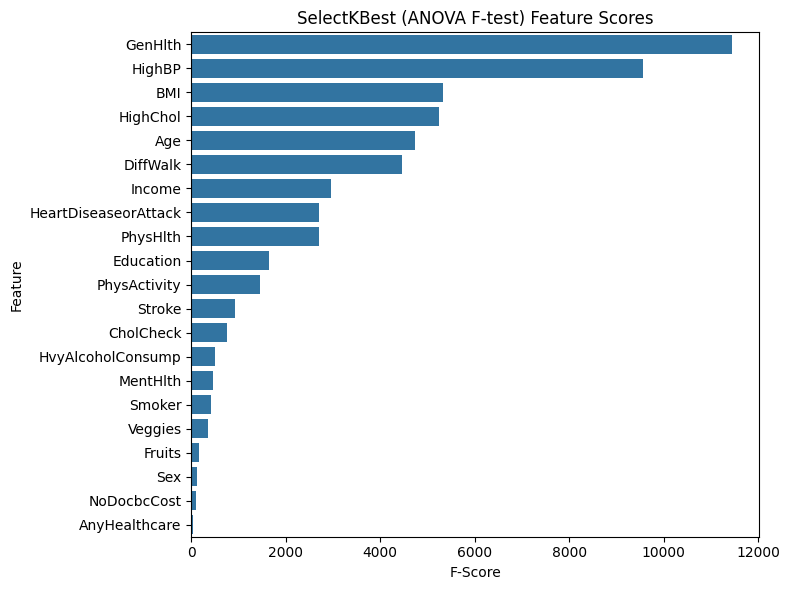

In [227]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=kbest_scores,
    x="F-Score",
    y="Feature"
)

plt.title(f"SelectKBest (ANOVA F-test) Feature Scores")
plt.xlabel("F-Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The top-`k` selected features (in original column order):

In [228]:
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask]
dropped_features = X_train.columns[~selected_mask]

print(f"Selected ({len(selected_features)}):", list(selected_features))
print(f"Dropped ({len(dropped_features)}):", list(dropped_features))

Selected (18): ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']
Dropped (3): ['AnyHealthcare', 'NoDocbcCost', 'Sex']


Reducing the train/test feature sets to the selected columns, ready to feed into modeling:

In [229]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

X_train_selected.shape, X_test_selected.shape

((56553, 18), (14139, 18))

In [230]:
X_train_scaled_selected = X_train_scaled[selected_features]
X_test_scaled_selected = X_test_scaled[selected_features]
X_train_scaled_selected.shape, X_test_scaled_selected.shape

((56553, 18), (14139, 18))

**Comparing with Mutual Information:** `GenHlth`, `HighBP`, `BMI`, `HighChol`, `Age`, and `DiffWalk` rank highly under both Mutual Information and the ANOVA F-test, which is a good sign; two different scoring methods agreeing on the strongest predictors gives more confidence in the ranking than either one alone. Features like `NoDocbcCost` and `HvyAlcoholConsump` score low under both methods and are the most likely candidates to drop if a smaller feature set is needed. The exact value of `k` above is a starting point, it can be tuned later based on downstream model performance (e.g. cross-validated accuracy/AUC for a few different `k` values).

## 7. Model Building, Training & Testing

In [109]:
#importing libraries
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score, classification_report, roc_curve, auc, roc_auc_score

**Helper Functions to Evaluate The Model**

In [110]:
model_comparison = {}
fine_tuned_model_comparison = {}

In [ ]:
def add_model_comparison(model_name, y_test, y_pred, y_pred_proba):
    scores = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_pred_proba)
    }
    if ("fine-tuned" in model_name.lower()):
        fine_tuned_model_comparison[model_name] = scores
    else:
        model_comparison[model_name] = scores

In [ ]:
def show_classification_report(y_pred, model_name):
    print(f"\nAccuracy ({model_name}): {accuracy_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report ({model_name}):")
    print(classification_report(y_test, y_pred))

In [ ]:
def show_confusion_matrix(y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix ({model_name})')
    plt.show()

In [ ]:
def plot_roc_curve(model, X_test, y_pred, model_name="Model"):
    # Predict probabilities
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

    # Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure(figsize=(6, 4))
    plt.plot(
        fpr, tpr,
        lw=2,
        label=f'ROC curve (AUC = {roc_auc:.2f})'
    )
    plt.plot(
        [0, 1], [0, 1],
        lw=2,
        linestyle='--'
    )

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve ({model_name})')
    plt.legend(loc='lower right')
    plt.show()

    # Add model metrics to comparison dictionary
    add_model_comparison(
        model_name,
        y_test,
        y_pred,
        y_pred_proba,
    )

    return roc_auc

### 7.1 Distance Based Algorithms

#### 7.1.1 Logistic Regression

In [ ]:
#importing libraries
from sklearn.linear_model import LogisticRegression

In [ ]:
#initialize your model
lr_model = LogisticRegression(max_iter=1000)
#train your model
lr_model.fit(X_train_scaled_selected,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Evaluate the model on the test set
y_pred_lr = lr_model.predict(X_test_scaled_selected)

show_classification_report(y_pred_lr, "Logistic Regression")


Accuracy (Logistic Regression): 0.7455

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      7070
           1       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



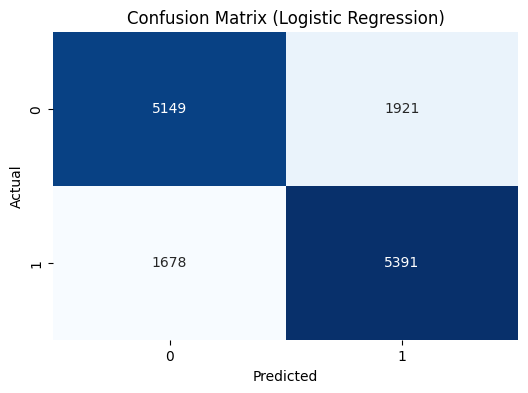

In [ ]:
show_confusion_matrix(y_pred_lr, "Logistic Regression")

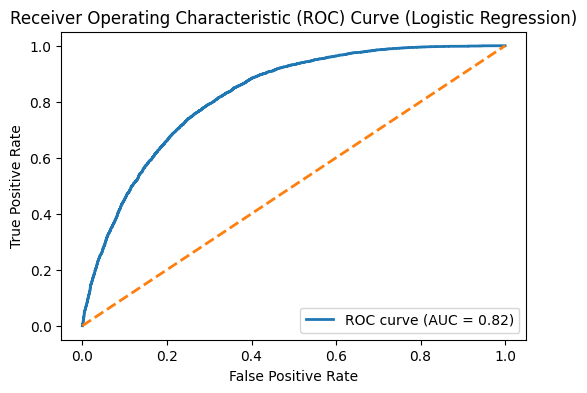

np.float64(0.8224746952798871)

In [ ]:
plot_roc_curve(lr_model, X_test_scaled_selected, y_pred_lr, "Logistic Regression")

#### 7.1.2 K-Nearest Neighbors

In [ ]:
#importing and training the model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_scaled_selected, y_train)

KNeighborsClassifier()

In [ ]:
#prediction
y_pred_knn = knn.predict(X_test_scaled_selected)

In [ ]:
show_classification_report(y_pred_knn, "K-Nearest Neighbors")


Accuracy (K-Nearest Neighbors): 0.7094

Classification Report (K-Nearest Neighbors):
              precision    recall  f1-score   support

           0       0.72      0.68      0.70      7070
           1       0.70      0.73      0.72      7069

    accuracy                           0.71     14139
   macro avg       0.71      0.71      0.71     14139
weighted avg       0.71      0.71      0.71     14139



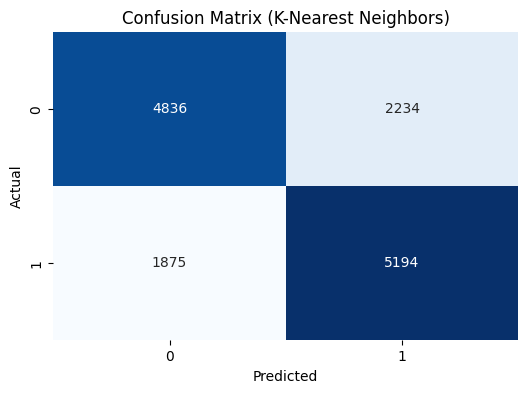

In [ ]:
show_confusion_matrix(y_pred_knn, "K-Nearest Neighbors")

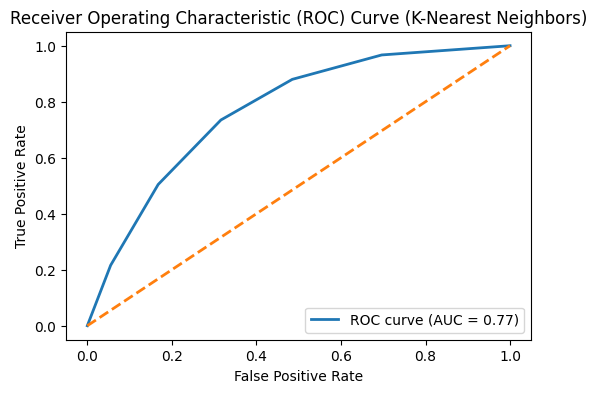

np.float64(0.7686682475009419)

In [ ]:
plot_roc_curve(knn, X_test_scaled_selected, y_pred_knn, "K-Nearest Neighbors")

#### 7.1.3 SVM

In [ ]:
#import libraries
from sklearn.svm import SVC

# Initialize and train the SVM model (using scaled data)
svm_model = SVC(probability=True, random_state=42) # probability=True for ROC curve
svm_model.fit(X_train_scaled_selected, y_train)

SVC(probability=True, random_state=42)

In [ ]:
#making predictions
y_pred_svm = svm_model.predict(X_test_scaled_selected)

In [ ]:
show_classification_report(y_pred_svm, "Support Vector Machine")


Accuracy (Support Vector Machine): 0.7486

Classification Report (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.79      0.68      0.73      7070
           1       0.72      0.82      0.77      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



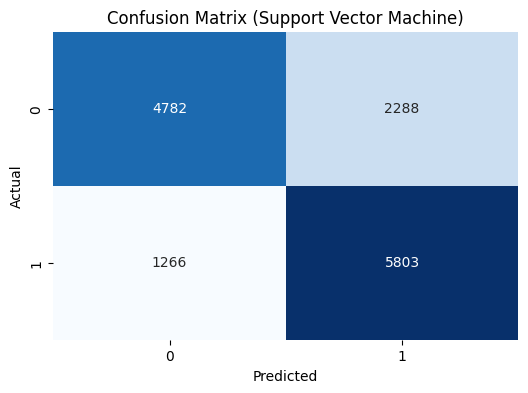

In [ ]:
show_confusion_matrix(y_pred_svm, "Support Vector Machine")

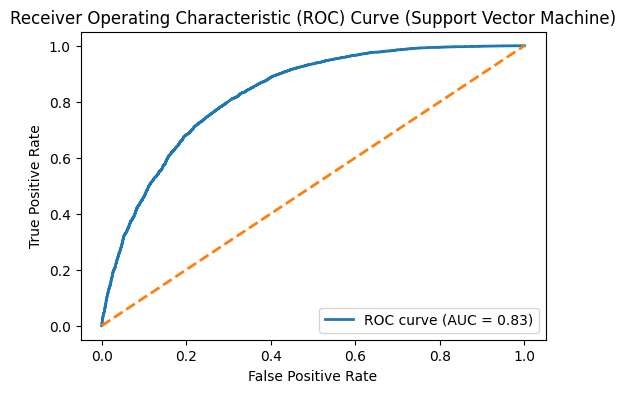

np.float64(0.8277139983868848)

In [ ]:
plot_roc_curve(svm_model, X_test_scaled_selected, y_pred_svm, "Support Vector Machine")

### 7.2 Tree Based Algorithms

#### 7.2.1 Decision Tree


In [123]:
#importing libraries for model building
from sklearn.tree import DecisionTreeClassifier

#initializing the model
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

#training the model
dt_model.fit(X_train_selected, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [124]:
#make predictions
y_pred_dt = dt_model.predict(X_test_selected)

In [125]:
show_classification_report(y_pred_dt, "Decision Tree Classifier")

NameError: name 'show_classification_report' is not defined

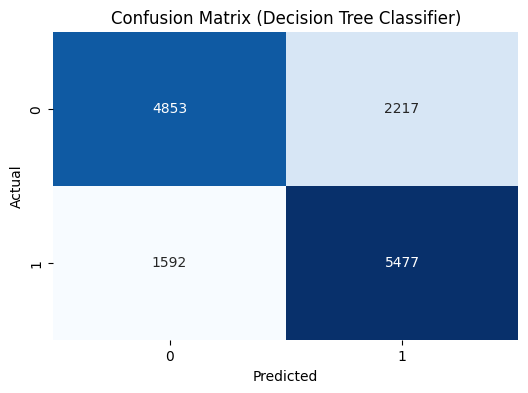

In [ ]:
show_confusion_matrix(y_pred_dt, "Decision Tree Classifier")

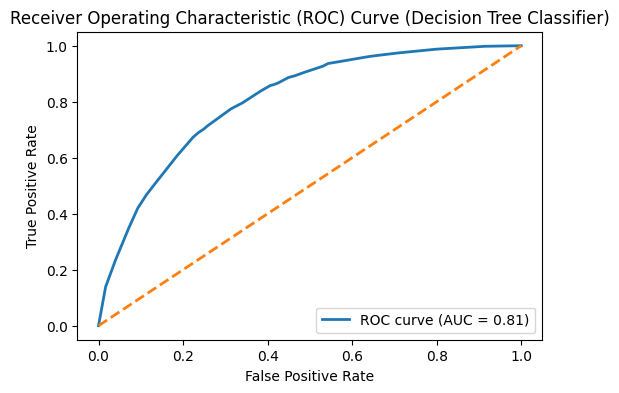

np.float64(0.8057872260560333)

In [ ]:
plot_roc_curve(dt_model, X_test_selected, y_pred_dt, "Decision Tree Classifier")

#### 7.2.2 Random Forest

In [ ]:
#importing the model
from sklearn.ensemble import RandomForestClassifier

#initializing the model
rf_model = RandomForestClassifier()

#training the model
rf_model.fit(X_train_selected, y_train)

RandomForestClassifier()

In [ ]:
#making predictions
y_pred_rf = rf_model.predict(X_test_selected)

In [ ]:
show_classification_report(y_pred_rf, "Random Forest Classifier")


Accuracy (Random Forest Classifier): 0.7319

Classification Report (Random Forest Classifier):
              precision    recall  f1-score   support

           0       0.75      0.70      0.72      7070
           1       0.72      0.77      0.74      7069

    accuracy                           0.73     14139
   macro avg       0.73      0.73      0.73     14139
weighted avg       0.73      0.73      0.73     14139



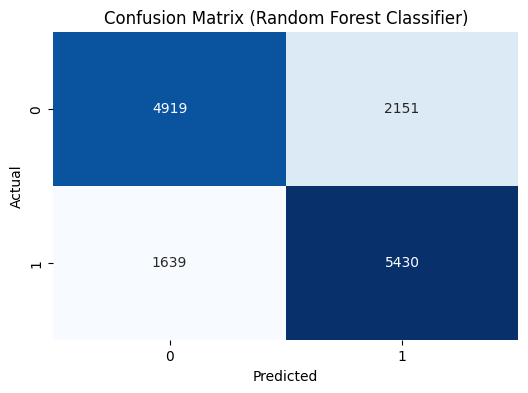

In [ ]:
show_confusion_matrix(y_pred_rf, "Random Forest Classifier")

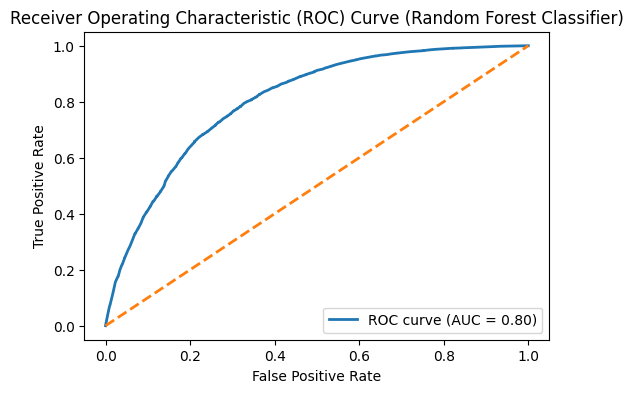

np.float64(0.8045345706286167)

In [ ]:
plot_roc_curve(rf_model, X_test_selected, y_pred_rf, "Random Forest Classifier")

#### 7.2.3 XG Boost

In [ ]:
#import xgboost
from xgboost import XGBClassifier

# Initialize and train the XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_selected, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test_selected)

In [ ]:
show_classification_report(y_pred_xgb, "XGBoost Classifier")


Accuracy (XGBoost Classifier): 0.7450

Classification Report (XGBoost Classifier):
              precision    recall  f1-score   support

           0       0.77      0.70      0.73      7070
           1       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.74     14139
weighted avg       0.75      0.75      0.74     14139



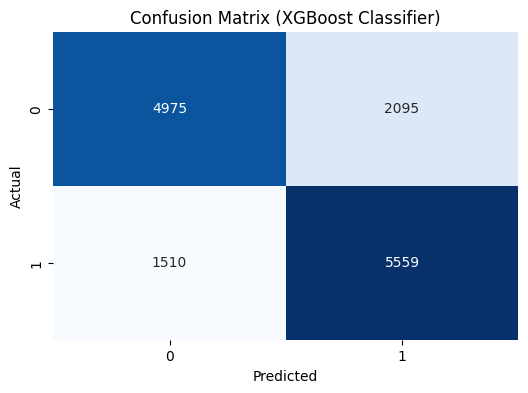

In [ ]:
show_confusion_matrix(y_pred_xgb, "XGBoost Classifier")

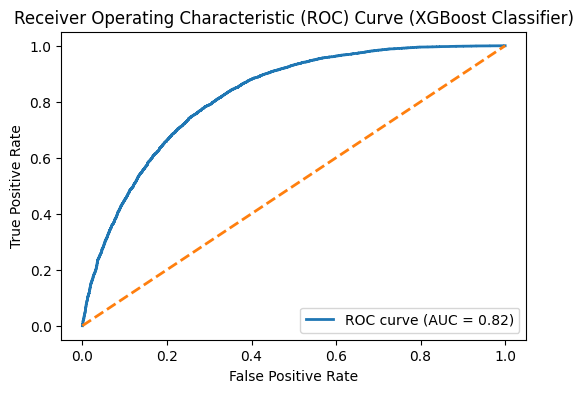

np.float64(0.8216987012041139)

In [ ]:
plot_roc_curve(xgb_model, X_test_selected, y_pred_xgb, "XGBoost Classifier")

#### 7.2.4 Gradient Boosting

In [120]:
#importing the model
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_selected, y_train)

GradientBoostingClassifier(random_state=42)

In [121]:
#making predictions
y_pred_gb = gb_model.predict(X_test_selected)

In [126]:
from sklearn.metrics import classification_report

print("Fine-tuned Gradient Boosting Classifier")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_gb_tuned,
        target_names=[
            "No Diabetes",
            "Prediabetes/Diabetes"
        ],
        digits=4
    )
)

Fine-tuned Gradient Boosting Classifier
                      precision    recall  f1-score   support

         No Diabetes     0.7736    0.7072    0.7389      7070
Prediabetes/Diabetes     0.7303    0.7930    0.7604      7069

            accuracy                         0.7501     14139
           macro avg     0.7520    0.7501    0.7497     14139
        weighted avg     0.7520    0.7501    0.7497     14139



In [129]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_gb_tuned
)

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)


Confusion Matrix:
[[5000 2070]
 [1463 5606]]

TN: 5000
FP: 2070
FN: 1463
TP: 5606


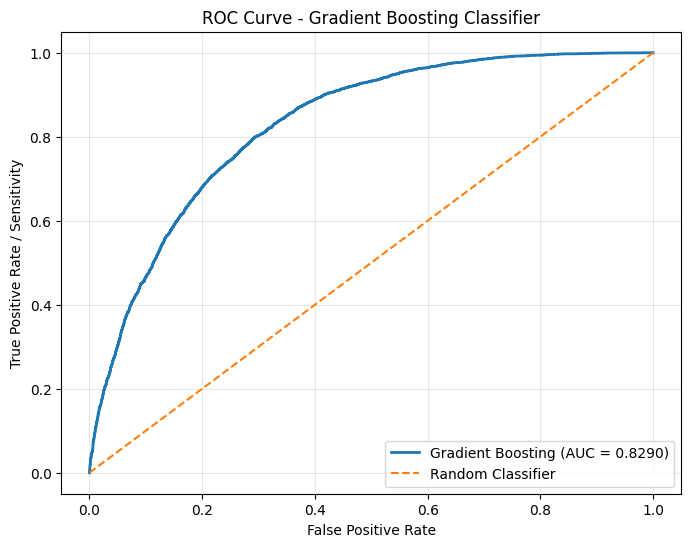

Gradient Boosting ROC-AUC: 0.8290


In [134]:
# ============================================================
# ROC CURVE - GRADIENT BOOSTING
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Get probability of positive class
y_prob_gb = gb_model.predict_proba(
    X_test_selected
)[:, 1]

# Calculate ROC curve
fpr_gb, tpr_gb, thresholds_gb = roc_curve(
    y_test,
    y_prob_gb
)

# Calculate ROC-AUC
roc_auc_gb = roc_auc_score(
    y_test,
    y_prob_gb
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_gb,
    tpr_gb,
    linewidth=2,
    label=f"Gradient Boosting (AUC = {roc_auc_gb:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")

plt.title(
    "ROC Curve - Gradient Boosting Classifier"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.show()

print(f"Gradient Boosting ROC-AUC: {roc_auc_gb:.4f}")

In [132]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00


#### 7.2.5 Cat Boost

In [133]:
#importing the model
from catboost import CatBoostClassifier

# Initialize and train the CatBoost model
catboost_model = CatBoostClassifier(random_state=42, verbose=False)
catboost_model.fit(X_train_selected, y_train)

CatBoostClassifier(random_state=42, verbose=False)

In [137]:
#making predictions
y_pred_catboost = catboost_model.predict(X_test_selected)

In [ ]:
show_classification_report(y_pred_catboost, "CatBoost Classifier")


Accuracy (CatBoost Classifier): 0.7486

Classification Report (CatBoost Classifier):
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      7070
           1       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



CatBoost Confusion Matrix:
[[4985 2085]
 [1469 5600]]

True Negative (TN): 4985
False Positive (FP): 2085
False Negative (FN): 1469
True Positive (TP): 5600


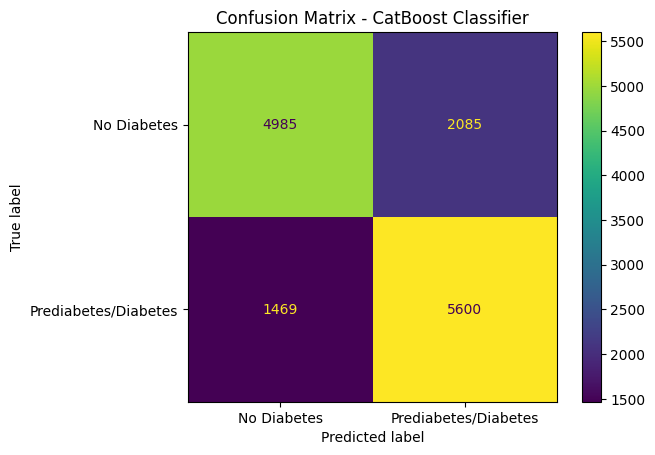

In [138]:
# ============================================================
# CONFUSION MATRIX - CATBOOST
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_catboost = confusion_matrix(
    y_test,
    y_pred_catboost
)

print("CatBoost Confusion Matrix:")
print(cm_catboost)

# Extract values
tn, fp, fn, tp = cm_catboost.ravel()

print("\nTrue Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_catboost,
    display_labels=[
        "No Diabetes",
        "Prediabetes/Diabetes"
    ]
)

disp.plot()
plt.title("Confusion Matrix - CatBoost Classifier")
plt.show()

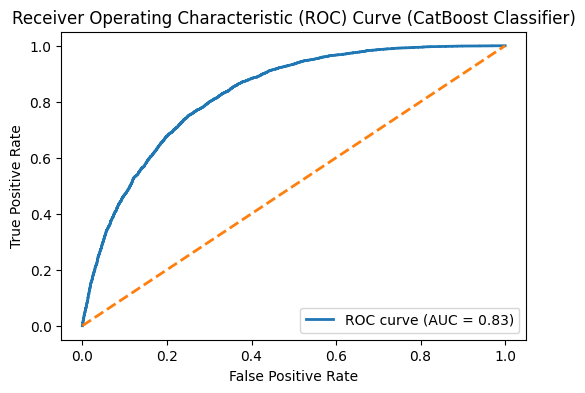

np.float64(0.8275096877955684)

In [ ]:
plot_roc_curve(catboost_model, X_test_selected, y_pred_catboost, "CatBoost Classifier")

#### 7.2.6 LightGBM

In [148]:
#import lightgbm
from lightgbm import LGBMClassifier

#initialize and train the LightGBM model
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_selected, y_train)

[LightGBM] [Info] Number of positive: 28277, number of negative: 28276
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 191
[LightGBM] [Info] Number of data points in the train set: 56553, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500009 -> initscore=0.000035
[LightGBM] [Info] Start training from score 0.000035


LGBMClassifier(random_state=42)

In [149]:
#making predictions
y_pred_lgbm = lgbm_model.predict(X_test_selected)

In [150]:
from sklearn.metrics import classification_report

print("LightGBM Classifier")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_lgbm,
        target_names=[
            "No Diabetes",
            "Prediabetes/Diabetes"
        ],
        digits=4
    )
)

LightGBM Classifier
                      precision    recall  f1-score   support

         No Diabetes     0.7749    0.7041    0.7378      7070
Prediabetes/Diabetes     0.7288    0.7954    0.7607      7069

            accuracy                         0.7498     14139
           macro avg     0.7519    0.7498    0.7492     14139
        weighted avg     0.7519    0.7498    0.7492     14139



LightGBM Classifier
True Negative  (TN): 4,978
False Positive (FP): 2,092
False Negative (FN): 1,446
True Positive  (TP): 5,623


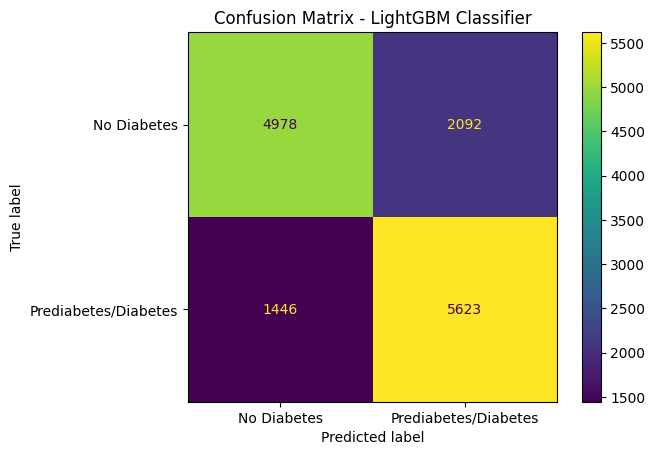

In [151]:
# ============================================================
# LIGHTGBM CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# If y_pred_lgbm already exists, use it directly
cm_lgbm = confusion_matrix(
    y_test,
    y_pred_lgbm,
    labels=[0, 1]
)

tn, fp, fn, tp = cm_lgbm.ravel()

print("LightGBM Classifier")
print("=" * 50)
print(f"True Negative  (TN): {tn:,}")
print(f"False Positive (FP): {fp:,}")
print(f"False Negative (FN): {fn:,}")
print(f"True Positive  (TP): {tp:,}")

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=[
        "No Diabetes",
        "Prediabetes/Diabetes"
    ]
)

disp.plot()

plt.title("Confusion Matrix - LightGBM Classifier")
plt.show()

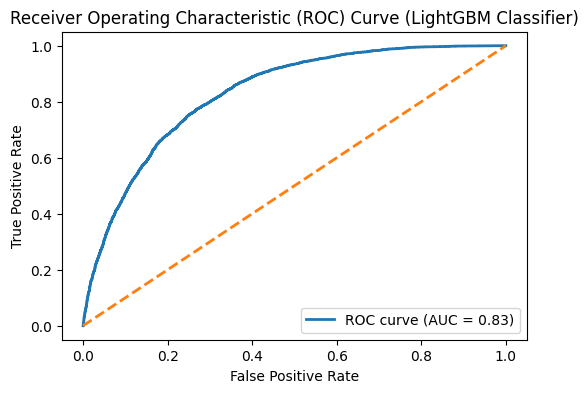

np.float64(0.8295092143856586)

In [ ]:
plot_roc_curve(lgbm_model, X_test_selected, y_pred_lgbm, "LightGBM Classifier")

## 8. Model Comparison

In [156]:
# ============================================================
# FINAL MEDICAL-FOCUSED MODEL COMPARISON
# ============================================================
#
# Models:
#   Gradient Boosting
#   LightGBM
#   CatBoost
#   XGBoost
#   Logistic Regression
#   Ridge
#   Lasso
#
# Medical priority:
#   1. Sensitivity
#   2. FNR
#   3. NPV
#
# Additional:
#   Specificity, F2, PR-AUC, MCC, ROC-AUC,
#   Accuracy, Precision, TP, TN, FP, FN
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)


# ============================================================
# STEP 1 — CREATE MODEL LIST
# ============================================================

models_for_comparison = {

    "Gradient Boosting": (
        best_gb_model,
        X_test_selected
    ),

    # # "LightGBM": (
    # #     best_lgbm_model,
    # #     X_test_selected
    # ),

    # "CatBoost": (
    #     best_catboost_model,
    #     X_test_selected
    # ),

    "XGBoost": (
        best_xgb_model,
        X_test_selected
    ),

    # "Logistic Regression": (
    #     best_lr_model,
    #     X_test_scaled_selected
    # ),

    # "Ridge": (
    #     ridge_random_search.best_estimator_,
    #     X_test_scaled_selected
    # ),

    # "Lasso": (
    #     lasso_random_search.best_estimator_,
    #     X_test_scaled_selected
    # )
}


# ============================================================
# STEP 2 — MEDICAL EVALUATION FUNCTION
# ============================================================

def evaluate_model_medical(
    model_name,
    model,
    X_test,
    y_test
):

    # --------------------------------------------------------
    # Get prediction score
    # --------------------------------------------------------

    if hasattr(model, "predict_proba"):

        y_score = model.predict_proba(X_test)[:, 1]

        y_pred = (
            y_score >= 0.50
        ).astype(int)

    elif hasattr(model, "decision_function"):

        y_score = model.decision_function(X_test)

        y_pred = (
            y_score >= 0
        ).astype(int)

    else:

        y_pred = model.predict(X_test)

        y_score = y_pred


    # Make sure predictions are 1-dimensional
    y_pred = np.asarray(y_pred).astype(int).ravel()


    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()


    # --------------------------------------------------------
    # Medical Metrics
    # --------------------------------------------------------

    # Sensitivity / Recall
    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )


    # False Negative Rate
    fnr = (
        fn / (tp + fn)
        if (tp + fn) > 0
        else 0
    )


    # Specificity
    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    # Negative Predictive Value
    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )


    # Precision
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )


    # F2 Score
    f2 = fbeta_score(
        y_test,
        y_pred,
        beta=2,
        zero_division=0
    )


    # ROC-AUC
    roc_auc = roc_auc_score(
        y_test,
        y_score
    )


    # PR-AUC
    pr_auc = average_precision_score(
        y_test,
        y_score
    )


    # MCC
    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )


    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    # --------------------------------------------------------
    # Return results
    # --------------------------------------------------------

    return {

        "Model": model_name,

        "Sensitivity": sensitivity,

        "FNR": fnr,

        "Specificity": specificity,

        "NPV": npv,

        "F2 Score": f2,

        "PR-AUC": pr_auc,

        "MCC": mcc,

        "ROC-AUC": roc_auc,

        "Accuracy": accuracy,

        "Precision": precision,

        "TP": tp,

        "TN": tn,

        "FP": fp,

        "FN": fn
    }


# ============================================================
# STEP 3 — RUN EVALUATION
# ============================================================

medical_results = []


for model_name, (model, X_eval) in models_for_comparison.items():

    print(f"Evaluating {model_name}...")

    result = evaluate_model_medical(
        model_name,
        model,
        X_eval,
        y_test
    )

    medical_results.append(result)


# ============================================================
# STEP 4 — CREATE DATAFRAME
# ============================================================

medical_comparison = pd.DataFrame(
    medical_results
)


# ============================================================
# STEP 5 — SORT BY MEDICAL PRIORITY
# ============================================================

medical_comparison = medical_comparison.sort_values(
    by=[
        "Sensitivity",
        "FNR",
        "NPV"
    ],
    ascending=[
        False,
        True,
        False
    ]
).reset_index(drop=True)


# ============================================================
# STEP 6 — DISPLAY FINAL TABLE
# ============================================================

print("=" * 120)
print("FINAL MEDICAL-FOCUSED MODEL COMPARISON")
print("=" * 120)

display(
    medical_comparison[
        [
            "Model",
            "Sensitivity",
            "FNR",
            "Specificity",
            "NPV",
            "F2 Score",
            "PR-AUC",
            "MCC",
            "ROC-AUC",
            "Accuracy",
            "Precision",
            "TP",
            "TN",
            "FP",
            "FN"
        ]
    ]
)

NameError: name 'best_xgb_model' is not defined

In [153]:
print("lgbm_random_search" in globals())

False


## 9. Fine Tuning

In [108]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

Fine tuning our top 6 models (based on ROC AUC and Recall)

### 9.1 Gradient Boosting Fine Tuning

In [116]:
show_classification_report(
    y_pred_gb_tuned,
    "Fine-tuned Gradient Boosting Classifier"
)

NameError: name 'show_classification_report' is not defined

In [102]:
from sklearn.ensemble import GradientBoostingClassifier

In [117]:
gb_param_dist = {
    'n_estimators': randint(100, 400),
    'learning_rate': uniform(0.01, 0.29),   # 0.01 - 0.3
    'max_depth': randint(2, 6),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'subsample': uniform(0.6, 0.4),         # 0.6 - 1.0
    'max_features': uniform(0.5, 0.5),      # 0.5 - 1.0
}

gb_tuned = GradientBoostingClassifier(random_state=42)

gb_random_search = RandomizedSearchCV(
    estimator=gb_tuned,
    param_distributions=gb_param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [104]:
gb_random_search.fit(X_train_selected, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78842de073b0>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78843aedca10>,
                                        'max_features': <scipy.stats._distn_infrastructu...
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78842e053470>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78842e053fe0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78842df3df70>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78842e053ef0>},
                   random_state=42, scoring='roc_auc', verbose=1)

In [105]:
print("Best parameters found: ", gb_random_search.best_params_)
print("Best ROC AUC score found: ", gb_random_search.best_score_)

Best parameters found:  {'learning_rate': np.float64(0.03161968666713354), 'max_depth': 4, 'max_features': np.float64(0.7117007403531848), 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 235, 'subsample': np.float64(0.602208846849441)}
Best ROC AUC score found:  0.8300702800081808


In [106]:
#making predictions with the best model
best_gb_model = gb_random_search.best_estimator_
y_pred_gb_tuned = best_gb_model.predict(X_test_selected)

In [114]:
show_classification_report(y_pred_gb_tuned, "Fine-tuned Gradient Boosting Classifier")

NameError: name 'show_classification_report' is not defined

In [113]:
show_confusion_matrix(y_pred_gb_tuned, "Fine-tuned Gradient Boosting Classifier")

NameError: name 'show_confusion_matrix' is not defined

In [112]:
plot_roc_curve(best_gb_model, X_test_selected, y_pred_gb_tuned, "Fine-tuned Gradient Boosting Classifier")

NameError: name 'plot_roc_curve' is not defined

### 9.2 LightGBM Fine Tuning

In [ ]:
# Define the parameter distribution for RandomizedSearchCV for LightGBM
lgbm_param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.29),   # 0.01 - 0.3
    'max_depth': randint(3, 12),
    'num_leaves': randint(20, 150),
    'subsample': uniform(0.6, 0.4),         # 0.6 - 1.0
    'colsample_bytree': uniform(0.6, 0.4),  # 0.6 - 1.0
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
    'min_child_samples': randint(5, 100),
}

In [ ]:
# Initialize LightGBM Classifier
lgbm_tuned = LGBMClassifier(random_state=42)

In [ ]:
# Initialize RandomizedSearchCV
lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm_tuned,
    param_distributions=lgbm_param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
# Perform random search on the training data
lgbm_random_search.fit(X_train_selected, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 28277, number of negative: 28276
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 191
[LightGBM] [Info] Number of data points in the train set: 56553, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500009 -> initscore=0.000035
[LightGBM] [Info] Start training from score 0.000035
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

RandomizedSearchCV(cv=5, estimator=LGBMClassifier(random_state=42), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c380a38c80>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c38c816690>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_...
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c3a8a07920>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c380a38860>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c380a39280>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c380a39130>},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
# Print the best parameters and best score
print("Best parameters found: ", lgbm_random_search.best_params_)
print("Best ROC AUC score found: ", lgbm_random_search.best_score_)

Best parameters found:  {'colsample_bytree': np.float64(0.6277445203500661), 'learning_rate': np.float64(0.03922562039945373), 'max_depth': 4, 'min_child_samples': 39, 'n_estimators': 314, 'num_leaves': 100, 'reg_alpha': np.float64(0.6557226353807422), 'reg_lambda': np.float64(0.38539662096556504), 'subsample': np.float64(0.8726454675891159)}
Best ROC AUC score found:  0.8301923346028481


In [ ]:
# Get the best estimator
best_lgbm_model = lgbm_random_search.best_estimator_

# Evaluate the best model on the test set
y_pred_lgbm_tuned = best_lgbm_model.predict(X_test_selected)

In [ ]:
show_classification_report(y_pred_lgbm_tuned, "Fine-tuned LightGBM Classifier")


Accuracy (Fine-tuned LightGBM Classifier): 0.7503

Classification Report (Fine-tuned LightGBM Classifier):
              precision    recall  f1-score   support

           0       0.78      0.71      0.74      7070
           1       0.73      0.80      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



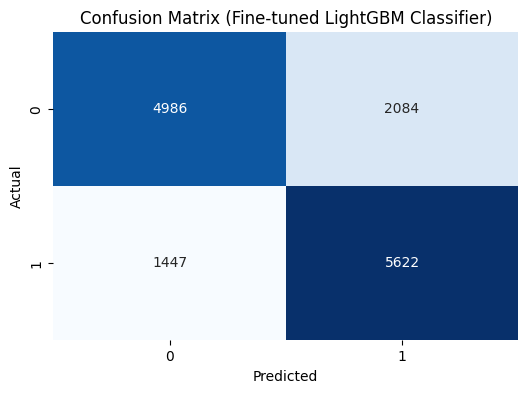

In [ ]:
show_confusion_matrix(y_pred_lgbm_tuned, "Fine-tuned LightGBM Classifier")

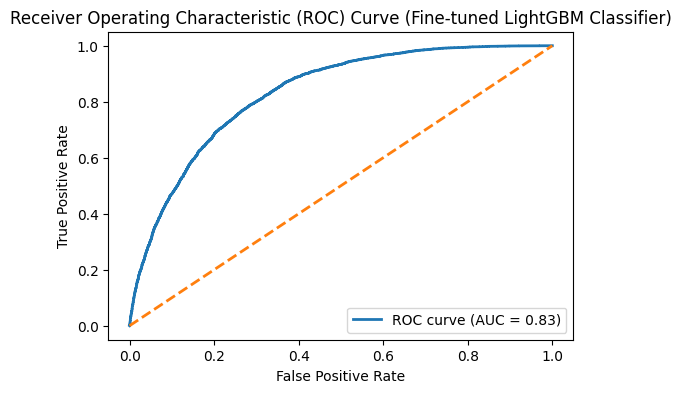

np.float64(0.8298396008790299)

In [ ]:
plot_roc_curve(best_lgbm_model, X_test_selected, y_pred_lgbm_tuned, "Fine-tuned LightGBM Classifier")

In [ ]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Ridge Classifier
ridge = RidgeClassifier()

# Hyperparameter distribution
ridge_param_dist = {
    'alpha': loguniform(1e-4, 1e4),
    'class_weight': [None, 'balanced']
}

# Initialize RandomizedSearchCV
ridge_random_search = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=ridge_param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Perform random search
ridge_random_search.fit(X_train_scaled_selected, y_train)

# Best parameters
print("Best Ridge Parameters:")
print(ridge_random_search.best_params_)

print("Best Ridge ROC-AUC:")
print(ridge_random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Ridge Parameters:
{'alpha': np.float64(0.003697114486625516), 'class_weight': None}
Best Ridge ROC-AUC:
0.8233023106679033


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Lasso-style Logistic Regression
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

# Hyperparameter distribution
lasso_param_dist = {
    'C': loguniform(1e-4, 1e4),
    'class_weight': [None, 'balanced']
}

# Initialize RandomizedSearchCV
lasso_random_search = RandomizedSearchCV(
    estimator=lasso,
    param_distributions=lasso_param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Perform random search
lasso_random_search.fit(X_train_scaled_selected, y_train)

# Best parameters
print("Best Lasso Parameters:")
print(lasso_random_search.best_params_)

print("Best Lasso ROC-AUC:")
print(lasso_random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Lasso Parameters:
{'C': np.float64(0.2854697857797185), 'class_weight': None}
Best Lasso ROC-AUC:
0.8242143154920253


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Ridge": ridge_random_search.best_estimator_,
    "Lasso": lasso_random_search.best_estimator_
}

for name, model in models.items():

    y_pred = model.predict(X_test_scaled_selected)

    # RidgeClassifier does not have predict_proba()
    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_scaled_selected)
    else:
        y_score = model.predict_proba(X_test_scaled_selected)[:, 1]

    print(f"\n{name} Results")
    print("-" * 40)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_score))


Ridge Results
----------------------------------------
Accuracy : 0.744536388712073
Precision: 0.7323564995295067
Recall   : 0.770688923468666
F1 Score : 0.7510339123242349
ROC-AUC  : 0.8217336867166901

Lasso Results
----------------------------------------
Accuracy : 0.7452436523092156
Precision: 0.737173347927213
Recall   : 0.7622011599943415
F1 Score : 0.7494783697315343
ROC-AUC  : 0.8225017872924855


### 9.3 CatBoost Fine Tuning

In [ ]:
catboost_param_dist = {
    'iterations': randint(100, 500),
    'learning_rate': uniform(0.01, 0.29),   # 0.01 - 0.3
    'depth': randint(3, 10),
    'l2_leaf_reg': uniform(1, 9),           # 1 - 10
    'border_count': randint(32, 255),
}

catboost_tuned = CatBoostClassifier(random_state=42, verbose=False, thread_count=1)

catboost_random_search = RandomizedSearchCV(
    estimator=catboost_tuned,
    param_distributions=catboost_param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
catboost_random_search.fit(X_train_selected, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=CatBoostClassifier(random_state=42, thread_count=1, verbose=False),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'border_count': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c380a40a40>,
                                        'depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c3a8fc6f90>,
                                        'iterations': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c38c11ade0>,
                                        'l2_leaf_reg': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c38c06bf50>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c38c04ebd0>},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
print("Best parameters found: ", catboost_random_search.best_params_)
print("Best ROC AUC score found: ", catboost_random_search.best_score_)

Best parameters found:  {'border_count': 248, 'depth': 6, 'iterations': 287, 'l2_leaf_reg': np.float64(5.884264748424236), 'learning_rate': np.float64(0.050868025242681164)}
Best ROC AUC score found:  0.8304974894623154


In [ ]:
best_catboost_model = catboost_random_search.best_estimator_
y_pred_catboost_tuned = best_catboost_model.predict(X_test_selected)

In [ ]:
show_classification_report(y_pred_catboost_tuned, "Fine-tuned CatBoost Classifier")


Accuracy (Fine-tuned CatBoost Classifier): 0.7517

Classification Report (Fine-tuned CatBoost Classifier):
              precision    recall  f1-score   support

           0       0.78      0.71      0.74      7070
           1       0.73      0.80      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



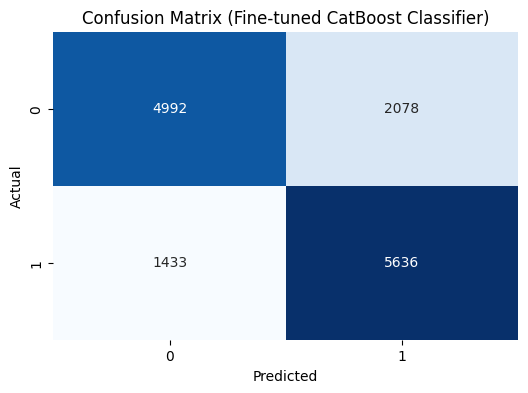

In [ ]:
show_confusion_matrix(y_pred_catboost_tuned, "Fine-tuned CatBoost Classifier")

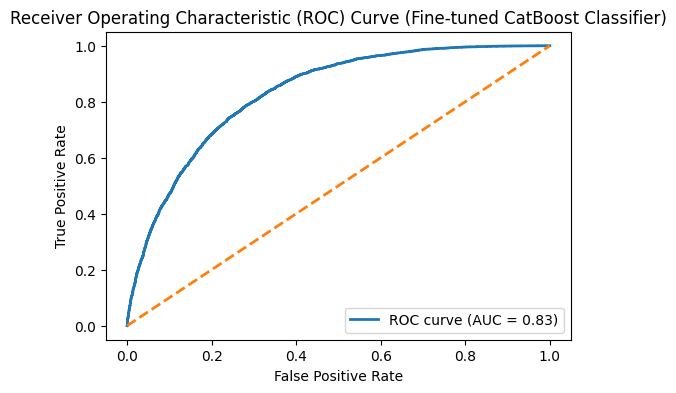

np.float64(0.8304694601586344)

In [ ]:
plot_roc_curve(best_catboost_model, X_test_selected, y_pred_catboost_tuned, "Fine-tuned CatBoost Classifier")

### 9.4 SVM Fine Tuning

In [87]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

In [88]:
param_dist_svm = [
    {
        'kernel': ['linear'],
        'C': loguniform(1e-2, 1e2)
    },
    {
        'kernel': ['rbf'],
        'C': loguniform(1e-2, 1e2),
        'gamma': loguniform(1e-4, 1e-1)
    },
    {
        'kernel': ['poly'],
        'C': loguniform(1e-2, 1e2),
        'gamma': loguniform(1e-4, 1e-1),
        'degree': [2],
        'coef0': uniform(-1, 2)
    }
]

In [89]:
svm_tuned = SVC(random_state=42, probability=False, max_iter=50000)  # raised from 10000 — see note above

random_search_svm = RandomizedSearchCV(
    estimator=svm_tuned,
    param_distributions=param_dist_svm,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

In [90]:
random_search_svm.fit(X_train_scaled_selected, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
print(random_search_svm.best_params_)
print(random_search_svm.best_score_)

In [ ]:
best_svm = random_search_svm.best_estimator_

In [ ]:
y_pred_svm_fine_tuned = best_svm.predict(X_test_scaled_selected)

In [ ]:
show_classification_report(y_pred_svm_fine_tuned, "Fine-tuned Support Vector Machine")

In [ ]:
show_confusion_matrix(y_pred_svm_fine_tuned, "Fine-tuned Support Vector Machine")

Refitting the best svm model with Probability=True to get the roc curve:

In [ ]:
best_params = {
    'C': 35.387588647792406,
    'gamma': 0.0026100256506134765,
    'kernel': 'rbf'
}

final_svm = SVC(**best_params, random_state=42, probability=True)
final_svm.fit(X_train_scaled_selected, y_train)

y_pred_svm_tuned = final_svm.predict(X_test_scaled_selected)

In [ ]:
plot_roc_curve(final_svm, X_test_scaled_selected, y_pred_svm_tuned, "Fine-tuned Support Vector Machine")

### 9.5 XGBoost Fine Tuning

In [ ]:
# Define the parameter distribution for RandomizedSearchCV
xg_param_dist = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'lambda': uniform(1, 2),
    'alpha': uniform(0, 0.5),
}

In [ ]:
# Initialize XGBoost Classifier
xgb_tuned = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

In [ ]:
# Initialize RandomizedSearchCV
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=xg_param_dist,
    n_iter=50, # Number of parameter settings that are sampled. Reduce for faster execution.
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

In [ ]:
# Perform random search on the training data
xgb_random_search.fit(X_train_selected, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c36c28ea20>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c380a46ea0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c380a47050>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c36c2a8b90>},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
# Print the best parameters and best score
print("Best parameters found: ", xgb_random_search.best_params_)
print("Best ROC AUC score found: ", xgb_random_search.best_score_)

Best parameters found:  {'alpha': np.float64(0.4714548519562596), 'colsample_bytree': np.float64(0.7292811728083021), 'gamma': np.float64(0.25939531087168305), 'lambda': np.float64(2.4060379177903557), 'learning_rate': np.float64(0.11908888071378819), 'max_depth': 3, 'n_estimators': 541, 'subsample': np.float64(0.9849789179768444)}
Best ROC AUC score found:  0.829736648205806


In [ ]:
# Get the best estimator
best_xgb_model = xgb_random_search.best_estimator_

In [ ]:
# Evaluate the best model on the test set
y_pred_xgb_tuned = best_xgb_model.predict(X_test_selected)

In [ ]:
show_classification_report(y_pred_xgb_tuned, "Fine-tuned XGBoost Classifier")


Accuracy (Fine-tuned XGBoost Classifier): 0.7510

Classification Report (Fine-tuned XGBoost Classifier):
              precision    recall  f1-score   support

           0       0.78      0.70      0.74      7070
           1       0.73      0.80      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



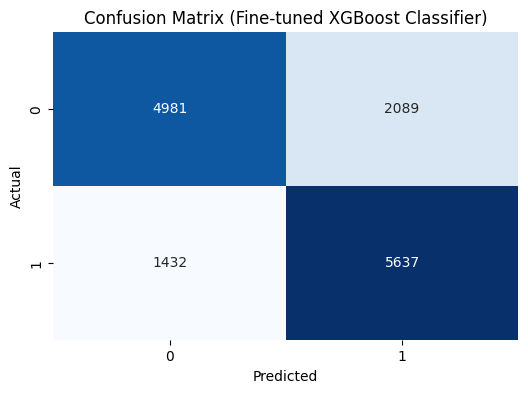

In [ ]:
show_confusion_matrix(y_pred_xgb_tuned, "Fine-tuned XGBoost Classifier")

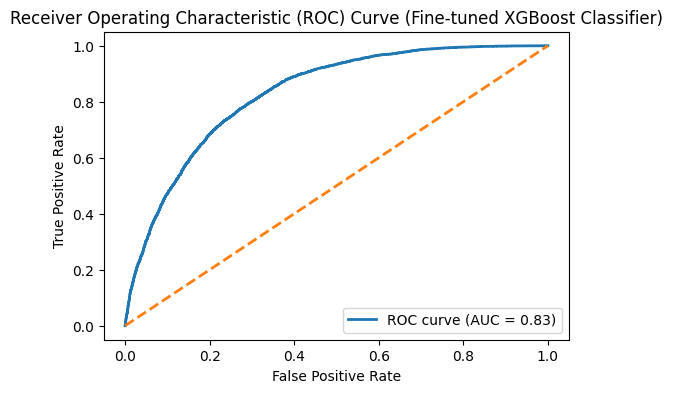

np.float64(0.8293708030140565)

In [ ]:
plot_roc_curve(best_xgb_model, X_test_selected, y_pred_xgb_tuned, "Fine-tuned XGBoost Classifier")

### 9.6 Logistic Regression Fine Tuning

In [ ]:
# Define the parameter distribution for RandomizedSearchCV for Logistic Regression
param_dist_lr = {
    'C': uniform(loc=0, scale=4), # Inverse of regularization strength; must be a positive float. Smaller values specify stronger regularization.
    'penalty': ['l1', 'l2'], # Regularization type. 'l1' for lasso, 'l2' for ridge.
    'solver': ['liblinear', 'saga'] # Solvers that support both 'l1' and 'l2' penalties.
}

In [ ]:
# Initialize Logistic Regression Classifier
lr_tuned = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence

# Initialize RandomizedSearchCV
random_search_lr = RandomizedSearchCV(
    estimator=lr_tuned,
    param_distributions=param_dist_lr,
    n_iter=50, # Number of parameter settings that are sampled. Reduce for faster execution.
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

In [ ]:
# Perform random search on the scaled and selected training data
random_search_lr.fit(X_train_scaled_selected, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=1000, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79c36c28e270>,
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear', 'saga']},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
# Print the best parameters and best score
print("Best parameters found for Logistic Regression: ", random_search_lr.best_params_)
print("Best ROC AUC score found for Logistic Regression: ", random_search_lr.best_score_)

Best parameters found for Logistic Regression:  {'C': np.float64(0.23233444867279784), 'penalty': 'l2', 'solver': 'liblinear'}
Best ROC AUC score found for Logistic Regression:  0.8242415325064771


In [ ]:
# Get the best estimator
best_lr_model = random_search_lr.best_estimator_

# Evaluate the best model on the test set
y_pred_lr_tuned = best_lr_model.predict(X_test_scaled_selected)

show_classification_report(y_pred_lr_tuned, "Fine-tuned Logistic Regression")


Accuracy (Fine-tuned Logistic Regression): 0.7452

Classification Report (Fine-tuned Logistic Regression):
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      7070
           1       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



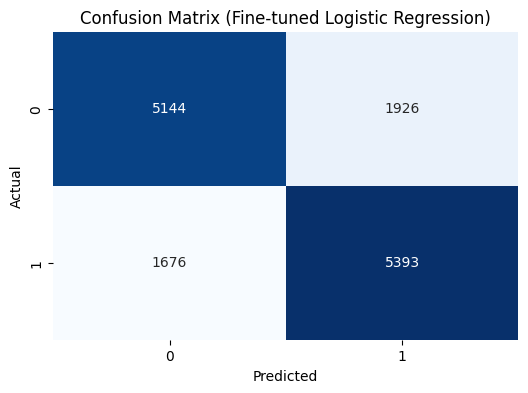

In [ ]:
show_confusion_matrix(y_pred_lr_tuned, "Fine-tuned Logistic Regression")

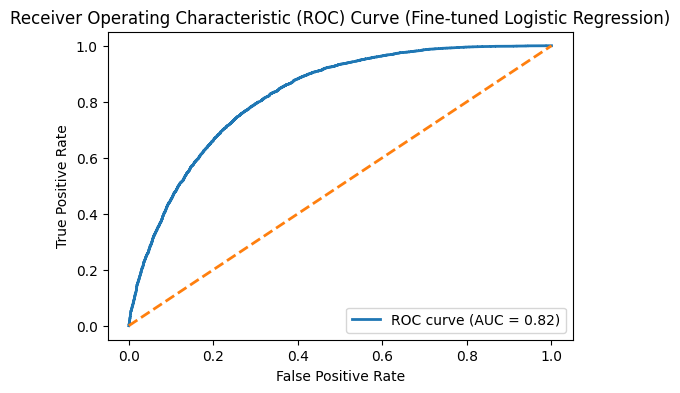

np.float64(0.8225740193201666)

In [ ]:
plot_roc_curve(best_lr_model, X_test_scaled_selected, y_pred_lr_tuned, "Fine-tuned Logistic Regression")

## 10. Model Comparison After Fine Tuning

In [ ]:
fine_tuned_comparison_df = pd.DataFrame(fine_tuned_model_comparison).T

### 10.1 Comparison Based on Recall and Precision

In [ ]:
comparison_df = fine_tuned_comparison_df.sort_values(['Recall', 'Precision'], ascending=False)

print("=" * 80)
print("MODEL COMPARISON BASED ON RECALL AND PRECISION SCORES")
print("=" * 80)

comparison_df

MODEL COMPARISON BASED ON RECALL AND PRECISION SCORES


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Fine-tuned XGBoost Classifier,0.750972,0.729614,0.797425,0.762014,0.829371
Fine-tuned CatBoost Classifier,0.751680,0.730620,0.797284,0.762497,0.830469
Fine-tuned LightGBM Classifier,0.750265,0.729561,0.795303,0.761015,0.829840
Fine-tuned Gradient Boosting Classifier,0.750124,0.730328,0.793040,0.760393,0.829523
Fine-tuned Logistic Regression,0.745244,0.736849,0.762908,0.749652,0.822574


### 10.2 Comparison Based on ROC AUC

In [ ]:
comparison_df = fine_tuned_comparison_df.sort_values("ROC AUC", ascending=False)

print("=" * 80)
print("MODEL COMPARISON BASED ON ROC AUC SCORE")
print("=" * 80)

comparison_df

MODEL COMPARISON BASED ON ROC AUC SCORE


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Fine-tuned CatBoost Classifier,0.751680,0.730620,0.797284,0.762497,0.830469
Fine-tuned LightGBM Classifier,0.750265,0.729561,0.795303,0.761015,0.829840
Fine-tuned Gradient Boosting Classifier,0.750124,0.730328,0.793040,0.760393,0.829523
Fine-tuned XGBoost Classifier,0.750972,0.729614,0.797425,0.762014,0.829371
Fine-tuned Logistic Regression,0.745244,0.736849,0.762908,0.749652,0.822574


### 10.3 Overall Model Comparison (Based on Recall and Precision)

In [ ]:
overall_comparison_df = pd.concat([pd.DataFrame(model_comparison).T, pd.DataFrame(fine_tuned_model_comparison).T])

In [ ]:
comparison_df = overall_comparison_df.sort_values(['Recall', 'Precision'], ascending=False)

print("=" * 80)
print("MODEL COMPARISON BASED ON RECALL AND PRECISION SCORES")
print("=" * 80)

comparison_df

MODEL COMPARISON BASED ON RECALL AND PRECISION SCORES


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Fine-tuned XGBoost Classifier,0.750972,0.729614,0.797425,0.762014,0.829371
Fine-tuned CatBoost Classifier,0.751680,0.730620,0.797284,0.762497,0.830469
LightGBM Classifier,0.749770,0.728840,0.795445,0.760687,0.829509
Fine-tuned LightGBM Classifier,0.750265,0.729561,0.795303,0.761015,0.829840
Gradient Boosting Classifier,0.752387,0.733020,0.793889,0.762241,0.828986
Fine-tuned Gradient Boosting Classifier,0.750124,0.730328,0.793040,0.760393,0.829523
CatBoost Classifier,0.748639,0.728692,0.792191,0.759116,0.827510
XGBoost Classifier,0.745031,0.726287,0.786391,0.755145,0.821699
Decision Tree Classifier,0.730603,0.711853,0.774791,0.741990,0.805787
Random Forest Classifier,0.731947,0.716264,0.768143,0.741297,0.804535


In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
param_grid_search_lr = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

In [ ]:
grid_search_lr = GridSearchCV(
    estimator=lr_tuned,
    param_grid=param_grid_search_lr,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)

In [ ]:
grid_search_lr.fit(X_train_scaled_selected, y_train)

In [ ]:
print("Best Parameters:", grid_search_lr.best_params_)
print("Best CV ROC-AUC:", grid_search_lr.best_score_)

In [ ]:
best_lr_model_grid = grid_search_lr.best_estimator_

In [ ]:
y_pred_best_lr_model_grid = best_lr_model_grid.predict(X_test_scaled_selected)

In [ ]:
show_classification_report(y_pred_best_lr_model_grid, "Fine-tuned Logistic Regression Model (Grid Search)")

In [ ]:
show_confusion_matrix(y_pred_best_lr_model_grid, "Fine-tuned Logistic Regression Model (Grid Search)")

In [92]:
# ============================================================
# FINE-TUNED MODELS FROM YOUR NOTEBOOK
# ============================================================

fine_tuned_models = {

    "Gradient Boosting": best_gb_model,

    "LightGBM": best_lgbm_model,

    "CatBoost": best_catboost_model,

    "XGBoost": best_xgb_model,

    "Logistic Regression": best_lr_model,

    "Ridge": ridge_random_search.best_estimator_,

    "Lasso": lasso_random_search.best_estimator_
}

print("Models available for evaluation:")
for name in fine_tuned_models:
    print("✓", name)

NameError: name 'best_gb_model' is not defined

In [91]:
# ============================================================
# MEDICAL-FOCUSED EVALUATION OF FINE-TUNED MODELS
# ============================================================
#
# Primary objective:
#   Reduce False Negatives in a medical/diabetes prediction task
#
# Metrics:
#   1. Sensitivity / Recall
#   2. False Negative Rate (FNR)
#   3. Specificity
#   4. NPV
#   5. F2 Score
#   6. PR-AUC
#   7. MCC
#   8. ROC-AUC
#
# Additional:
#   Accuracy, Precision, TP, TN, FP, FN
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)


# ============================================================
# 1. MEDICAL EVALUATION FUNCTION
# ============================================================

def medical_evaluation(
    model_name,
    model,
    X_test,
    y_test,
    threshold=0.50
):

    # --------------------------------------------------------
    # STEP 1: Get prediction score
    # --------------------------------------------------------

    if hasattr(model, "predict_proba"):

        # Models such as:
        # XGBoost, CatBoost, LightGBM,
        # Logistic Regression, Lasso Logistic Regression
        y_score = model.predict_proba(X_test)[:, 1]

        # Probability threshold
        y_pred = (y_score >= threshold).astype(int)

        threshold_used = threshold

    elif hasattr(model, "decision_function"):

        # Models such as RidgeClassifier and SVM
        y_score = model.decision_function(X_test)

        # decision_function uses 0 as the
        # natural classification boundary
        y_pred = (y_score >= 0).astype(int)

        threshold_used = 0

    else:

        # Fallback
        y_pred = model.predict(X_test)
        y_score = y_pred

        threshold_used = "N/A"


    # --------------------------------------------------------
    # STEP 2: Confusion Matrix
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()


    # --------------------------------------------------------
    # STEP 3: Medical Metrics
    # --------------------------------------------------------

    # Sensitivity / Recall
    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )


    # False Negative Rate
    fnr = (
        fn / (tp + fn)
        if (tp + fn) > 0
        else 0
    )


    # Specificity
    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    # Negative Predictive Value
    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )


    # Precision / Positive Predictive Value
    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )


    # F2 Score
    # Gives more importance to recall
    f2 = fbeta_score(
        y_test,
        y_pred,
        beta=2,
        zero_division=0
    )


    # PR-AUC
    pr_auc = average_precision_score(
        y_test,
        y_score
    )


    # ROC-AUC
    roc_auc = roc_auc_score(
        y_test,
        y_score
    )


    # Matthews Correlation Coefficient
    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )


    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    # --------------------------------------------------------
    # STEP 4: Return results
    # --------------------------------------------------------

    return {

        "Model": model_name,

        # Medical priority metrics
        "Sensitivity": sensitivity,
        "FNR": fnr,
        "Specificity": specificity,
        "NPV": npv,

        # Additional medical metrics
        "F2 Score": f2,
        "PR-AUC": pr_auc,
        "MCC": mcc,
        "ROC-AUC": roc_auc,

        # Traditional metrics
        "Accuracy": accuracy,
        "Precision": precision,

        # Confusion matrix
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,

        # Threshold
        "Threshold": threshold_used
    }


# ============================================================
# 2. DEFINE YOUR ACTUAL FINE-TUNED MODELS
# ============================================================

fine_tuned_models = {

    "Gradient Boosting":
        gb_random_search.best_estimator_,

    "LightGBM":
        lgbm_random_search.best_estimator_,

    "CatBoost":
        catboost_random_search.best_estimator_,

    "XGBoost":
        xgb_random_search.best_estimator_,

    "Logistic Regression":
        random_search_lr.best_estimator_,

    "Ridge":
        ridge_random_search.best_estimator_,

    "Lasso":
        lasso_random_search.best_estimator_
}


# ============================================================
# 3. EVALUATE ALL FINE-TUNED MODELS
# ============================================================

medical_results = []


for model_name, model in fine_tuned_models.items():

    print(f"Evaluating: {model_name}")

    # --------------------------------------------------------
    # Tree-based models
    # --------------------------------------------------------

    if model_name in [
        "Gradient Boosting",
        "LightGBM",
        "CatBoost",
        "XGBoost"
    ]:

        X_eval = X_test_selected


    # --------------------------------------------------------
    # Linear models
    # --------------------------------------------------------

    else:

        X_eval = X_test_scaled_selected


    # Evaluate model

    result = medical_evaluation(
        model_name=model_name,
        model=model,
        X_test=X_eval,
        y_test=y_test,
        threshold=0.50
    )

    medical_results.append(result)


# ============================================================
# 4. CREATE COMPARISON DATAFRAME
# ============================================================

medical_comparison = pd.DataFrame(
    medical_results
)


# ============================================================
# 5. SORT FOR MEDICAL PRIORITY
# ============================================================
#
# First priority:
#   Highest Sensitivity
#
# Second priority:
#   Lowest False Negative Rate
#
# Third priority:
#   Highest NPV
# ============================================================

medical_comparison = medical_comparison.sort_values(
    by=[
        "Sensitivity",
        "FNR",
        "NPV"
    ],
    ascending=[
        False,
        True,
        False
    ]
).reset_index(drop=True)


# ============================================================
# 6. DISPLAY MAIN MEDICAL COMPARISON
# ============================================================

medical_comparison[
    [
        "Model",
        "Sensitivity",
        "FNR",
        "Specificity",
        "NPV",
        "F2 Score",
        "PR-AUC",
        "MCC",
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "TP",
        "TN",
        "FP",
        "FN"
    ]
]

NameError: name 'gb_random_search' is not defined